# Assignment 04 — Giải phẫu mô hình: hiệu chỉnh xác suất, bộ lọc học được và độ nhạy che khuất

**Học phần:** Phát triển các Hệ thống Thông minh — Học viện Công nghệ Bưu chính Viễn thông
**Sinh viên:** Nguyễn Duy Nghĩa · **B23DCCN600** · Lớp **D23CTPM01**
**Giảng viên:** PGS.TS Trần Đình Quế
**Học kỳ:** Học kỳ 1 năm học 2026 – 2027

---

## Mục tiêu notebook

Các chương trước của báo cáo dừng lại ở việc **chấm điểm** mô hình: accuracy, F1, ma trận nhầm
lẫn. Notebook này đi một bước xa hơn và **mổ xẻ chính mô hình đã huấn luyện**, trả lời bốn câu
hỏi mà không bảng điểm nào trả lời được:

1. **Xác suất mà mô hình in ra có đáng tin không?** Khi mô hình nói "chắc 99%" thì nó đúng bao
   nhiêu phần trăm số lần? Báo cáo đo **sai số hiệu chỉnh kỳ vọng (ECE)** với 15 khoảng, vẽ
   **biểu đồ độ tin cậy**, rồi áp dụng **nhiệt độ scaling** và đo lại.
2. **Tầng tích chập đầu tiên đã học được gì?** Báo cáo vẽ toàn bộ kernel của tầng Conv đầu và
   lượng hóa xem chúng thiên về dò cạnh hay dò cường độ.
3. **Biểu diễn thay đổi ra sao theo độ sâu?** Báo cáo đẩy một ảnh qua từng khối và vẽ bản đồ
   đặc trưng, kèm kích thước tensor tại mỗi tầng.
4. **Mô hình thực sự nhìn vào đâu?** Báo cáo trượt một ô che 8×8 trên ảnh và ghi lại xác suất
   lớp đúng, tạo ra bản đồ nhiệt chỉ ra vùng ảnh chi phối quyết định.

### Vì sao đây là đóng góp gốc

Trong hai bài tham khảo mà báo cáo đối chiếu, một bài chỉ ghi "có thể bổ sung hiệu chỉnh xác
suất" vào phần hướng phát triển và không đo gì cả, bài còn lại không nhắc tới. Cả hai đều không
cho thấy mạng đã học được gì bên trong. Notebook này làm cả hai việc đó, **bằng số đo thật**,
trên mô hình đã huấn luyện ở các chương trước.

### Nguyên tắc chấp hành

- **Không huấn luyện lại.** Mọi mô hình được nạp từ trọng số đã lưu ở `mnist/models/` và
  `cifar10/models/`; notebook này chỉ suy luận.
- **Nhiệt độ `T` chỉ được khớp trên tập validation.** Khớp trên tập test sẽ là rò rỉ dữ liệu và
  làm vô hiệu toàn bộ mục hiệu chỉnh. Mỗi mục có ghi rõ nhánh dữ liệu đã dùng.
- **Không bịa số.** Nếu một phép đo cho kết quả trái với kỳ vọng nêu ở phần mở đầu, báo cáo giữ
  nguyên số đo và sửa phần diễn giải.

## 1. Thư viện, thiết bị và cấu hình

Theo Mục 1 của hợp đồng tích hợp, toàn bộ phần PyTorch **phải** chạy trên GPU và phải in ra tên
thiết bị. Notebook này chỉ suy luận nên chi phí tính toán rất nhẹ, nhưng vẫn giữ đúng ràng buộc
thiết bị để kết quả đồng nhất với các chương trước.

In [1]:
%matplotlib inline
import hashlib
import json
import os
import sys
import time

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split

# ----- hat giong: co dinh o moi noi de ket qua tai lap duoc -----
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ----- thiet bi: bat buoc GPU theo Muc 1 hop dong -----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert torch.cuda.is_available(), "Phai chay tren GPU; kiem tra lai venv"
print("Thiet bi          :", DEVICE, "|", torch.cuda.get_device_name(0))
print("PyTorch           :", torch.__version__)
print("NumPy             :", np.__version__)

# ----- cau hinh hinh ve theo Muc 5.2 hop dong -----
plt.rcParams["font.sans-serif"] = ["Segoe UI", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["figure.dpi"] = 100
DPI = 150

# ----- duong dan: luon tuong doi tu thu muc notebooks/ -----
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
FIG_DIR = os.path.join("..", "reports", "figures")
REPORT_DIR = os.path.join("..", "reports")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
print("Goc Assignment 04 :", ROOT)
print("Thu muc hinh      :", os.path.abspath(FIG_DIR))


def save_fig(fig, name):
    """Luu PNG dpi=150, nen trang, vien khit theo Muc 5.2 hop dong."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches="tight", facecolor="white")
    print(f"Da luu hinh: {path}  ({os.path.getsize(path) / 1024:.0f} KB)")


def sha1_of(path, n=12):
    """Van tay tep trong so, de bao cao ghi duoc dung phien ban mo hinh da dung."""
    h = hashlib.sha1()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()[:n]

Thiet bi          : cuda | NVIDIA GeForce RTX 4060 Laptop GPU
PyTorch           : 2.13.0+cu126
NumPy             : 2.5.1
Goc Assignment 04 : D:\Python\Intelligent-System-Development\src\Assignment 04
Thu muc hinh      : D:\Python\Intelligent-System-Development\src\Assignment 04\analysis\reports\figures


## 2. Cơ sở toán học của phần hiệu chỉnh xác suất

### 2.1 Độ tin cậy và sai số hiệu chỉnh kỳ vọng

Với một mẫu $x_i$, mạng cho ra véc-tơ logit $z_i \in \mathbb{R}^{10}$. Hàm softmax biến nó thành
phân phối xác suất

$$\hat{p}_{i,k} = \frac{\exp(z_{i,k})}{\sum_{j=1}^{10}\exp(z_{i,j})}.$$

Nhãn dự đoán là $\hat{y}_i = \arg\max_k \hat{p}_{i,k}$ và **độ tin cậy** là
$c_i = \max_k \hat{p}_{i,k}$.

Một mô hình được gọi là **hiệu chỉnh hoàn hảo** nếu với mọi mức tin cậy $c$,

$$\mathbb{P}\big(\hat{y} = y \;\big|\; c(x) = c\big) = c,$$

nghĩa là trong tất cả các lần mô hình nói "chắc 80%" thì đúng 80% số lần. Vì không ước lượng
được xác suất có điều kiện liên tục đó từ một tập hữu hạn, ta chia đoạn $[0,1]$ thành $B$ khoảng
**đều nhau** $I_1,\dots,I_B$ và so sánh theo từng khoảng. Với khoảng $b$ chứa tập chỉ số
$S_b = \{i : c_i \in I_b\}$, định nghĩa

$$\mathrm{acc}(b) = \frac{1}{|S_b|}\sum_{i \in S_b}\mathbb{1}[\hat{y}_i = y_i],
\qquad
\mathrm{conf}(b) = \frac{1}{|S_b|}\sum_{i \in S_b} c_i .$$

**Sai số hiệu chỉnh kỳ vọng** là trung bình có trọng số của độ lệch giữa hai đại lượng đó:

$$\boxed{\;\mathrm{ECE} \;=\; \sum_{b=1}^{B} \frac{|S_b|}{N}\,\big|\,\mathrm{acc}(b) - \mathrm{conf}(b)\,\big|\;}$$

Báo cáo dùng $B = 15$ khoảng đều. Trên **biểu đồ độ tin cậy**, trục hoành là độ tin cậy, trục
tung là độ chính xác thực nghiệm, và đường chéo $y = x$ là chuẩn hoàn hảo. Cột **nằm dưới đường
chéo** nghĩa là $\mathrm{acc} < \mathrm{conf}$, tức mô hình **quá tự tin**; cột **nằm trên** nghĩa
là mô hình **thiếu tự tin**.

### 2.2 Nhiệt độ scaling

Nhiệt độ scaling (Guo và cộng sự, 2017) là phép hiệu chỉnh **hậu huấn luyện** đơn giản nhất có
thể: chia toàn bộ véc-tơ logit cho một **vô hướng duy nhất** $T > 0$ trước khi lấy softmax,

$$\hat{p}^{(T)}_{i,k} = \frac{\exp(z_{i,k}/T)}{\sum_j \exp(z_{i,j}/T)} .$$

Vì cùng một $T$ áp cho mọi thành phần của $z_i$, thứ tự các logit **không đổi**, nên
$\arg\max$ không đổi và **accuracy giữ nguyên tuyệt đối**. Phép này chỉ làm phân phối nhọn hơn
hay tù đi:

- $T > 1$ kéo các xác suất về gần nhau, tức **giảm** độ tin cậy. Nếu quá trình tối ưu chọn
  $T > 1$ thì đó là bằng chứng trực tiếp rằng mô hình **quá tự tin**.
- $T < 1$ làm phân phối nhọn hơn, ứng với mô hình thiếu tự tin.
- $T = 1$ là không đổi.

Tham số $T$ được chọn bằng cách cực tiểu hóa **hàm hợp lý âm (NLL)** trên tập **validation**:

$$T^{\star} = \arg\min_{T>0} \; -\frac{1}{N_{\text{val}}}\sum_{i=1}^{N_{\text{val}}}
\log \hat{p}^{(T)}_{i,\,y_i}.$$

Hai điểm cần nhấn mạnh về phương pháp:

1. **Chỉ dùng validation.** Khớp $T$ trên tập test rồi báo cáo ECE cũng trên tập test là rò rỉ
   dữ liệu: con số thu được sẽ đẹp một cách giả tạo và không còn ý nghĩa ước lượng. Trong
   notebook này, tập validation là 20% dữ liệu huấn luyện được tách ra bằng
   `train_test_split(..., test_size=0.2, stratify=y, random_state=42)` — **đúng phép chia đã dùng
   khi huấn luyện**, và tập test 10 000 ảnh gốc chỉ được dùng để *báo cáo*.
2. **Tham số hóa qua $\log T$.** Thay vì tối ưu trực tiếp $T$ với ràng buộc $T>0$, báo cáo tối ưu
   $\theta = \log T$ không ràng buộc rồi đặt $T = e^{\theta}$. Cách này biến bài toán có ràng
   buộc thành bài toán không ràng buộc, nên dùng được L-BFGS trực tiếp mà không sợ bước cập nhật
   đẩy $T$ xuống số âm.

In [2]:
N_BINS = 15          # so khoang deu tren [0, 1] cho ECE, theo Muc 8.2 hop dong


def ece_bins(conf, correct, n_bins=N_BINS):
    """Tinh ECE va thong ke tung khoang.

    Tham so
    -------
    conf    : (N,) do tin cay c_i = max_k p_ik
    correct : (N,) 1.0 neu du doan dung, 0.0 neu sai

    Tra ve
    ------
    ece, bin_acc, bin_conf, bin_count, edges
    Khoang rong dong gop 0 vao tong, va duoc ghi acc = conf = 0 de giu do dai mang = n_bins.
    """
    conf = np.asarray(conf, dtype=np.float64)
    correct = np.asarray(correct, dtype=np.float64)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    # digitize tren cac moc trong: tra ve chi so khoang 0..n_bins-1
    idx = np.clip(np.digitize(conf, edges[1:-1], right=False), 0, n_bins - 1)
    n = len(conf)
    bin_acc, bin_conf, bin_count, ece = [], [], [], 0.0
    for b in range(n_bins):
        m = idx == b
        c = int(m.sum())
        a = float(correct[m].mean()) if c else 0.0
        f = float(conf[m].mean()) if c else 0.0
        bin_count.append(c)
        bin_acc.append(a)
        bin_conf.append(f)
        if c:
            ece += (c / n) * abs(a - f)
    return float(ece), bin_acc, bin_conf, bin_count, edges


def fit_temperature(logits_val, y_val, lr=0.05, max_iter=200):
    """Khop nhiet do T tren TAP VALIDATION bang L-BFGS, tham so hoa qua log T.

    Tra ve (T, nll_truoc, nll_sau) voi hai NLL deu do tren chinh tap validation.
    """
    lv = logits_val.detach().to(DEVICE)
    yv = y_val.detach().to(DEVICE)
    log_t = torch.zeros(1, device=DEVICE, requires_grad=True)   # khoi tao T = exp(0) = 1
    opt = torch.optim.LBFGS([log_t], lr=lr, max_iter=max_iter)

    def closure():
        opt.zero_grad()
        loss = F.cross_entropy(lv / torch.exp(log_t), yv)
        loss.backward()
        return loss

    opt.step(closure)
    T = float(torch.exp(log_t).item())
    with torch.no_grad():
        nll0 = float(F.cross_entropy(lv, yv).item())
        nll1 = float(F.cross_entropy(lv / T, yv).item())
    return T, nll0, nll1


def evaluate(logits, y, n_bins=N_BINS):
    """Gom moi dai luong can cho mot bo logit: ECE, thong ke khoang, accuracy, NLL."""
    probs = torch.softmax(logits, dim=1).cpu().numpy().astype(np.float64)
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == y).astype(np.float64)
    ece, b_acc, b_conf, b_cnt, edges = ece_bins(conf, correct, n_bins)
    nll = float(F.cross_entropy(logits.cpu(), torch.from_numpy(y).long()).item())
    return dict(ece=ece, bin_acc=b_acc, bin_conf=b_conf, bin_count=b_cnt, edges=edges,
                accuracy=float(correct.mean()), mean_conf=float(conf.mean()), nll=nll,
                conf=conf, pred=pred, correct=correct, probs=probs)


@torch.no_grad()
def batched_logits(model, x_tensor, batch_size=1000):
    """Suy luan theo lo de khong tran bo nho GPU 8,6 GB."""
    out = []
    for i in range(0, len(x_tensor), batch_size):
        out.append(model(x_tensor[i:i + batch_size].to(DEVICE)).cpu())
    return torch.cat(out)


print("Da dinh nghia: ece_bins, fit_temperature, evaluate, batched_logits")
print(f"So khoang ECE: {N_BINS}  |  do rong moi khoang: {1 / N_BINS:.6f}")

Da dinh nghia: ece_bins, fit_temperature, evaluate, batched_logits
So khoang ECE: 15  |  do rong moi khoang: 0.066667


## 3. Nạp mô hình MNIST đã huấn luyện và tái tạo đúng phép chia

Notebook này **không huấn luyện lại**. Mô hình MNIST được nạp từ
`mnist/models/mnist_cnn_pytorch.pt`, kiến trúc lấy từ `mnist/models/mnist_cnn_def.py`, và hằng số
chuẩn hóa lấy từ `mnist/models/mnist_preproc.json`.

Điều quan trọng nhất ở bước này là **tái tạo chính xác nhánh validation** đã dùng lúc huấn luyện.
Nếu dùng một phép chia khác thì nhiệt độ $T$ sẽ được khớp trên những ảnh mà mô hình đã thấy trong
lúc cập nhật trọng số, và phép hiệu chỉnh mất ý nghĩa. Vì phép chia là
`train_test_split(x_train, y_train, test_size=0.2, stratify=y_train, random_state=42)` với hạt
giống cố định, chỉ cần gọi lại đúng lệnh đó là thu được đúng 12 000 ảnh validation.

Báo cáo kiểm chứng việc tái tạo bằng hai cách: (a) so mean/std tính lại từ nhánh train với giá trị
đã ghi trong `mnist_preproc.json`, (b) so accuracy suy luận lại trên tập test với giá trị đã ghi
trong `mnist/reports/metrics_mnist.json`. Cả hai phải khớp thì mới đi tiếp.

In [3]:
def load_mnist_bundle():
    """Nap mo hinh + du lieu MNIST, tra ve mot 'bundle' dong nhat cho ca hai mien anh."""
    models_dir = os.path.join(ROOT, "mnist", "models")
    if models_dir not in sys.path:
        sys.path.insert(0, models_dir)
    from mnist_cnn_def import MnistCNN

    npz = np.load(os.path.join(ROOT, "mnist", "data", "mnist.npz"))
    pp = json.load(open(os.path.join(models_dir, "mnist_preproc.json"), encoding="utf-8"))
    mean, std = float(pp["mean"]), float(pp["std"])

    # tai tao DUNG phep chia da dung luc huan luyen
    x_tr, y_tr = npz["x_train"], npz["y_train"]
    x_fit, x_val, y_fit, y_val = train_test_split(
        x_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=SEED)
    x_te, y_te = npz["x_test"], npz["y_test"]

    def to_tensor(x01):
        """(N, 28, 28) float trong [0,1]  ->  tensor (N, 1, 28, 28) da chuan hoa."""
        x = (np.asarray(x01, dtype=np.float32) - mean) / std
        return torch.from_numpy(x).unsqueeze(1)

    ckpt = os.path.join(models_dir, "mnist_cnn_pytorch.pt")
    model = MnistCNN().to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()          # TAT Dropout va dong bang BatchNorm: bat buoc khi suy luan

    # kiem chung (a): mean/std tinh lai tu nhanh train phai khop file preproc
    mean_re = float((x_fit.astype(np.float64) / 255.0).mean())
    std_re = float((x_fit.astype(np.float64) / 255.0).std())

    return dict(
        key="mnist", name="MNIST", ckpt=ckpt, sha1=sha1_of(ckpt),
        classes=[str(i) for i in range(10)],
        x_val=x_val.astype(np.float32) / 255.0, y_val=y_val.astype(np.int64),
        x_test=x_te.astype(np.float32) / 255.0, y_test=y_te.astype(np.int64),
        to_tensor=to_tensor, model=model,
        blocks=[("Khoi 1", model.block1), ("Khoi 2", model.block2)],
        conv1=model.block1[0], cmap="gray", is_rgb=False,
        mean_re=mean_re, std_re=std_re, preproc=pp,
        metrics_path=os.path.join(ROOT, "mnist", "reports", "metrics_mnist.json"),
    )


BUNDLES = {}
t0 = time.time()
BUNDLES["mnist"] = load_mnist_bundle()
b = BUNDLES["mnist"]
print(f"Nap mo hinh MNIST trong {time.time() - t0:.2f}s")
print(f"  checkpoint      : {os.path.relpath(b['ckpt'], ROOT)}  (sha1 {b['sha1']})")
print(f"  so tham so      : {sum(p.numel() for p in b['model'].parameters()):,}")
print(f"  validation      : {b['x_val'].shape}   test: {b['x_test'].shape}")
print(f"  mean tinh lai   : {b['mean_re']:.10f}   file preproc: {b['preproc']['mean']:.10f}")
print(f"  std  tinh lai   : {b['std_re']:.10f}   file preproc: {b['preproc']['std']:.10f}")
assert abs(b["mean_re"] - b["preproc"]["mean"]) < 1e-6, "Phep chia KHONG khop file preproc"
assert abs(b["std_re"] - b["preproc"]["std"]) < 1e-6, "Phep chia KHONG khop file preproc"
print("  -> phep chia tai tao DUNG (mean/std khop den 1e-6)")

Nap mo hinh MNIST trong 4.79s
  checkpoint      : mnist\models\mnist_cnn_pytorch.pt  (sha1 c22e2ee6d3ac)
  so tham so      : 421,738
  validation      : (12000, 28, 28)   test: (10000, 28, 28)
  mean tinh lai   : 0.1307886794   file preproc: 0.1307886839
  std  tinh lai   : 0.3082403582   file preproc: 0.3082403541
  -> phep chia tai tao DUNG (mean/std khop den 1e-6)


In [4]:
# ----- kiem chung (b): accuracy suy luan lai phai khop metrics da cong bo -----
LOGITS = {}
for key, bd in BUNDLES.items():
    torch.cuda.synchronize()
    t0 = time.time()
    lg_val = batched_logits(bd["model"], bd["to_tensor"](bd["x_val"]))
    lg_test = batched_logits(bd["model"], bd["to_tensor"](bd["x_test"]))
    torch.cuda.synchronize()
    dt = time.time() - t0
    LOGITS[key] = dict(val=lg_val, test=lg_test)

    acc_now = float((lg_test.argmax(1).numpy() == bd["y_test"]).mean())
    acc_ref = json.load(open(bd["metrics_path"], encoding="utf-8"))["models"]["pytorch"]["accuracy"]
    print(f"[{bd['name']}] suy luan {len(bd['x_val']) + len(bd['x_test']):,} anh trong {dt:.2f}s "
          f"tren {torch.cuda.get_device_name(0)}")
    print(f"  accuracy tinh lai = {acc_now:.4f}   |   metrics da cong bo = {acc_ref:.4f}   "
          f"|   lech = {abs(acc_now - acc_ref):.6f}")
    assert abs(acc_now - acc_ref) < 1e-4, "Trong so KHONG khop metrics da cong bo"
    print("  -> trong so nap dung, notebook dang mo xe DUNG mo hinh da bao cao")

[MNIST] suy luan 22,000 anh trong 1.58s tren NVIDIA GeForce RTX 4060 Laptop GPU
  accuracy tinh lai = 0.9898   |   metrics da cong bo = 0.9898   |   lech = 0.000000
  -> trong so nap dung, notebook dang mo xe DUNG mo hinh da bao cao


### Nhận xét bước kiểm chứng

Hai phép kiểm đều khớp. Mean và std tính lại từ 48 000 ảnh nhánh train trùng với giá trị ghi
trong `mnist_preproc.json` tới sai số dưới $10^{-6}$, xác nhận rằng lệnh `train_test_split` ở
trên tái tạo **đúng** phép chia đã dùng lúc huấn luyện, nên 12 000 ảnh validation thực sự là
những ảnh mô hình chưa từng được cập nhật trọng số trên đó. Accuracy suy luận lại trên 10 000 ảnh
test bằng đúng 0,9898, trùng con số đã công bố trong `metrics_mnist.json`, xác nhận tệp trọng số
đang được mổ xẻ chính là mô hình đã báo cáo ở Chương 6 chứ không phải một bản huấn luyện khác.

Chỉ sau khi cả hai điều kiện này thỏa mãn thì mọi con số phía dưới mới có nghĩa.

---

## 4. Phần A — Hiệu chỉnh xác suất

Mục này trả lời câu hỏi: **xác suất mà mạng in ra có đáng tin không?** Quy trình gồm ba bước:

1. Tính ECE với 15 khoảng trên tập **test**, dùng logit gốc.
2. Khớp nhiệt độ $T$ bằng L-BFGS trên tập **validation** (và chỉ trên tập validation).
3. Chia logit test cho $T$ rồi tính lại ECE, so sánh trước và sau.

In [5]:
CALIB = {}
for key, bd in BUNDLES.items():
    lg_val, lg_test = LOGITS[key]["val"], LOGITS[key]["test"]

    # buoc 1: ECE trươc hieu chinh, do tren TAP TEST
    before = evaluate(lg_test, bd["y_test"])

    # buoc 2: khop T tren TAP VALIDATION (khong bao gio dung test o buoc nay)
    T, nll_val_before, nll_val_after = fit_temperature(
        lg_val, torch.from_numpy(bd["y_val"]))

    # buoc 3: ap T cho logit test roi do lai
    after = evaluate(lg_test / T, bd["y_test"])

    CALIB[key] = dict(before=before, after=after, T=T,
                      nll_val_before=nll_val_before, nll_val_after=nll_val_after)

    print(f"===== {bd['name']} =====")
    print(f"  Accuracy tren test            : {before['accuracy']:.4f}")
    print(f"  Do tin cay trung binh (truoc) : {before['mean_conf']:.4f}"
          f"   -> chenh so voi accuracy: {before['mean_conf'] - before['accuracy']:+.4f}")
    print(f"  ECE truoc hieu chinh          : {before['ece']:.6f}")
    print(f"  Nhiet do T khop tren val      : {T:.6f}"
          f"   ({'qua tu tin' if T > 1 else 'thieu tu tin'})")
    print(f"  NLL tren validation           : {nll_val_before:.6f} -> {nll_val_after:.6f}")
    print(f"  ECE sau hieu chinh            : {after['ece']:.6f}"
          f"   (giam {100 * (1 - after['ece'] / before['ece']):.1f}% tuong doi)")
    print(f"  Do tin cay trung binh (sau)   : {after['mean_conf']:.4f}")
    print(f"  NLL tren test                 : {before['nll']:.6f} -> {after['nll']:.6f}")
    print(f"  Accuracy sau hieu chinh       : {after['accuracy']:.4f}"
          f"   (phai KHONG doi vi T > 0 khong doi thu tu logit)")
    print()

===== MNIST =====
  Accuracy tren test            : 0.9898
  Do tin cay trung binh (truoc) : 0.9916   -> chenh so voi accuracy: +0.0018
  ECE truoc hieu chinh          : 0.002232
  Nhiet do T khop tren val      : 1.231759   (qua tu tin)
  NLL tren validation           : 0.039255 -> 0.037712
  ECE sau hieu chinh            : 0.001759   (giam 21.2% tuong doi)
  Do tin cay trung binh (sau)   : 0.9885
  NLL tren test                 : 0.030118 -> 0.030098
  Accuracy sau hieu chinh       : 0.9898   (phai KHONG doi vi T > 0 khong doi thu tu logit)



In [6]:
# ----- bang chi tiet 15 khoang, doc duoc tung con so -----
for key, bd in BUNDLES.items():
    c = CALIB[key]["before"]
    edges = c["edges"]
    print(f"===== {bd['name']}: thong ke {N_BINS} khoang (truoc hieu chinh) =====")
    print(f"{'khoang':>18} {'so mau':>8} {'acc(b)':>9} {'conf(b)':>9} {'acc-conf':>10} {'dong gop':>10}")
    n = len(c["conf"])
    for i in range(N_BINS):
        cnt = c["bin_count"][i]
        if cnt == 0:
            print(f"[{edges[i]:.4f},{edges[i+1]:.4f}) {0:>8} {'-':>9} {'-':>9} {'-':>10} {0.0:>10.6f}")
            continue
        a, f_ = c["bin_acc"][i], c["bin_conf"][i]
        print(f"[{edges[i]:.4f},{edges[i+1]:.4f}) {cnt:>8} {a:>9.4f} {f_:>9.4f} "
              f"{a - f_:>+10.4f} {(cnt / n) * abs(a - f_):>10.6f}")
    print(f"{'TONG (= ECE)':>18} {n:>8} {'':>9} {'':>9} {'':>10} {c['ece']:>10.6f}")
    print()

===== MNIST: thong ke 15 khoang (truoc hieu chinh) =====
            khoang   so mau    acc(b)   conf(b)   acc-conf   dong gop
[0.0000,0.0667)        0         -         -          -   0.000000
[0.0667,0.1333)        0         -         -          -   0.000000
[0.1333,0.2000)        0         -         -          -   0.000000
[0.2000,0.2667)        0         -         -          -   0.000000
[0.2667,0.3333)        0         -         -          -   0.000000
[0.3333,0.4000)        5    0.2000    0.3728    -0.1728   0.000086
[0.4000,0.4667)        6    0.5000    0.4195    +0.0805   0.000048
[0.4667,0.5333)       19    0.4211    0.5126    -0.0916   0.000174
[0.5333,0.6000)       29    0.5862    0.5671    +0.0191   0.000055
[0.6000,0.6667)       24    0.5000    0.6344    -0.1344   0.000323
[0.6667,0.7333)       28    0.7143    0.7043    +0.0100   0.000028
[0.7333,0.8000)       37    0.7838    0.7645    +0.0193   0.000071
[0.8000,0.8667)       59    0.8136    0.8311    -0.0175   0.000103
[0

In [7]:
# ----- ECE la mot TRUNG BINH: no noi gi va KHONG noi gi ve tung du doan rieng le? -----
TAIL = {}
for key, bd in BUNDLES.items():
    st = CALIB[key]["before"]
    conf, corr = st["conf"], st["correct"]
    print(f"===== {bd['name']}: duoi tin cay cao =====")
    print(f"  tong so anh bi phan loai sai: {int((corr == 0).sum())} / {len(corr)}")
    rows = []
    for th in (0.9, 14 / 15, 0.99, 0.999, 0.9999):
        m = conf >= th
        n_err = int(((corr == 0) & m).sum())
        rows.append((th, int(m.sum()), n_err, float(corr[m].mean())))
        print(f"  conf >= {th:.6f}: {int(m.sum()):5d} anh, {n_err:3d} anh SAI, "
              f"accuracy trong nhom = {corr[m].mean():.6f}")
    print(f"  do tin cay CAO NHAT trong cac anh sai: {conf[corr == 0].max():.6f}")

    # phan thuc: neu sua het cac anh sai co do tin cay cao, ECE thay doi the nao?
    c99 = corr.copy(); c99[(corr == 0) & (conf >= 0.99)] = 1.0
    ece99 = ece_bins(conf, c99)[0]
    clast = corr.copy(); clast[(corr == 0) & (conf >= 14 / 15)] = 1.0
    ecelast = ece_bins(conf, clast)[0]
    print(f"  ECE thuc te                                   : {st['ece']:.6f}")
    print(f"  ECE gia dinh moi anh sai co conf>=0.99 thanh dung : {ece99:.6f} "
          f"({ece99 - st['ece']:+.6f})")
    print(f"  ECE gia dinh moi anh sai o khoang cuoi thanh dung : {ecelast:.6f} "
          f"({ecelast - st['ece']:+.6f})")
    TAIL[key] = dict(rows=rows, max_conf_wrong=float(conf[corr == 0].max()),
                     n_wrong=int((corr == 0).sum()), ece_if_fix_099=float(ece99),
                     ece_if_fix_last_bin=float(ecelast))
    print()

===== MNIST: duoi tin cay cao =====
  tong so anh bi phan loai sai: 102 / 10000
  conf >= 0.900000:  9763 anh,  27 anh SAI, accuracy trong nhom = 0.997234
  conf >= 0.933333:  9710 anh,  22 anh SAI, accuracy trong nhom = 0.997734
  conf >= 0.990000:  9397 anh,   6 anh SAI, accuracy trong nhom = 0.999361
  conf >= 0.999000:  8725 anh,   2 anh SAI, accuracy trong nhom = 0.999771
  conf >= 0.999900:  7508 anh,   1 anh SAI, accuracy trong nhom = 0.999867
  do tin cay CAO NHAT trong cac anh sai: 0.999923
  ECE thuc te                                   : 0.002232
  ECE gia dinh moi anh sai co conf>=0.99 thanh dung : 0.001632 (-0.000600)
  ECE gia dinh moi anh sai o khoang cuoi thanh dung : 0.002371 (+0.000139)



### Diễn giải bảng hiệu chỉnh và bảng đuôi tin cậy cao

Kết quả ở đây **trái với kỳ vọng đặt ra ở đầu notebook**, và theo đúng quy tắc chung của Mục 8
hợp đồng tích hợp, báo cáo giữ nguyên số đo và sửa lại phần diễn giải.

**Kỳ vọng ban đầu** là mô hình sẽ quá tự tin rõ rệt, vì Chương 6 đã ghi nhận những ảnh bị phân
loại sai với độ tin cậy gần tuyệt đối. **Thực tế đo được** là mô hình MNIST đã gần như hiệu chỉnh
sẵn: ECE chỉ 0,002232, tức trung bình có trọng số của độ lệch giữa độ tin cậy và độ chính xác chỉ
vào khoảng 0,22 điểm phần trăm. Độ tin cậy trung bình 0,9916 so với accuracy 0,9898, tức mô hình
tự tin hơn thực lực đúng 0,0018.

#### Cấu trúc bên trong con số ECE

Đọc bảng 15 khoảng thì thấy một con số ECE gộp che mất khá nhiều cấu trúc:

- **Năm khoảng đầu hoàn toàn rỗng.** Mô hình không bao giờ cho ra dự đoán với độ tin cậy dưới
  0,3333. Với bài toán 10 lớp dùng softmax, độ tin cậy của lớp thắng luôn lớn hơn 0,1, và một
  mạng đã hội tụ hiếm khi để nhiều lớp chia đều xác suất.
- **Khoảng cuối chiếm gần như toàn bộ dữ liệu.** Có 9 710 trên 10 000 ảnh rơi vào
  $[0{,}9333;\,1)$, tức 97,1% tập test, với acc 0,9977 so với conf 0,9988, lệch $-0{,}0011$.
  Độ lệch nhỏ nhưng trọng số khổng lồ nên khoảng này đóng góp 0,001030 vào ECE, tức **46,2%
  toàn bộ ECE**.
- **Dấu của độ lệch không đồng nhất.** Khoảng $[0{,}6000;\,0{,}6667)$ có acc 0,5000 so với conf
  0,6344, tức quá tự tin 13,4 điểm phần trăm; nhưng khoảng $[0{,}5333;\,0{,}6000)$ có acc 0,5862
  so với conf 0,5671, tức **thiếu** tự tin 1,9 điểm phần trăm. ECE lấy trị tuyệt đối trước khi
  cộng nên hai chiều lệch không triệt tiêu nhau, nhưng cũng vì thế ECE không cho biết mô hình
  lệch về phía nào. Đại lượng trả lời câu hỏi đó là nhiệt độ $T$ ở mục sau.
- **Các khoảng giữa rất thưa.** Cộng cả chín khoảng từ $[0{,}3333;\,0{,}4000)$ đến
  $[0{,}8667;\,0{,}9333)$ cũng chỉ có 290 ảnh, tức 2,9% tập test. Ước lượng acc trên 5 hay 6 mẫu
  là cực kỳ nhiễu, nên các cột ở giữa biểu đồ độ tin cậy phải đọc một cách dè dặt. Đây là hạn chế
  cố hữu của ECE chia khoảng đều trên một mô hình có độ chính xác cao.

#### ECE thấp KHÔNG cho phép tin vào từng dự đoán riêng lẻ

Đây là điểm quan trọng nhất của mục này, và nó hoà giải một mâu thuẫn biểu kiến: Chương 6 và
Chương 7 mô tả những ảnh **sai với độ tin cậy rất cao**, trong khi notebook này đo được ECE chỉ
0,0022. Hai sự thật đó **không hề mâu thuẫn**, vì chúng nói về hai đại lượng khác nhau.

**ECE là một trung bình trên toàn bộ 10 000 dự đoán.** Một nhóm nhỏ dự đoán sai một cách tự tin
gần như không làm nó nhúc nhích, đơn giản vì trọng số $|S_b|/N$ của nhóm đó quá bé. Bảng đuôi tin
cậy cao cho thấy chính xác điều này:

| Ngưỡng độ tin cậy | Số ảnh | Số ảnh SAI | Accuracy trong nhóm |
|---|---|---|---|
| $\ge 0{,}9000$ | 9 763 | 27 | 0,997234 |
| $\ge 0{,}9333$ | 9 710 | 22 | 0,997734 |
| $\ge 0{,}9900$ | 9 397 | 6 | 0,999361 |
| $\ge 0{,}9990$ | 8 725 | 2 | 0,999771 |
| $\ge 0{,}9999$ | 7 508 | 1 | 0,999867 |

Trong tổng số 102 ảnh bị phân loại sai, có 27 ảnh mà mô hình vẫn tự tin từ 0,9 trở lên, 6 ảnh tự
tin từ 0,99 trở lên, và **một ảnh mà mô hình sai với độ tin cậy 0,999923**. Với một người dùng
nhìn vào một dự đoán đơn lẻ và thấy con số 0,9999, ECE toàn cục 0,0022 không bảo vệ được gì:
sáu ảnh kia chỉ chiếm 0,06% tập test, nên dù mô hình có sai trên chúng theo cách tệ đến mấy thì
ECE cũng gần như không đổi.

**Phản chứng định lượng.** Giả sử sửa được cả 6 ảnh sai có độ tin cậy từ 0,99 trở lên thành đúng,
ECE giảm từ 0,002232 xuống 0,001632, tức chỉ 0,0006. Nhưng nếu sửa cả **22** ảnh sai nằm trong
khoảng cuối thành đúng, ECE lại **tăng** lên 0,002371. Lý do rất rõ: khi đó acc của khoảng cuối
thành 1,0000 trong khi conf vẫn là 0,9988, nên khoảng ấy chuyển từ hơi quá tự tin sang hơi
**thiếu** tự tin, và $|{\rm acc}-{\rm conf}|$ tăng từ 0,0011 lên 0,0012.

Kết luận rút ra từ phản chứng đó là một điểm phương pháp luận đáng ghi lại: **một mô hình chính
xác hơn hẳn vẫn có thể có ECE tệ hơn.** ECE đo sự *khớp* giữa độ tin cậy và độ chính xác, không
đo bản thân độ chính xác, và không đo được rủi ro ở đuôi phân phối. Do đó ECE thấp là điều kiện
cần chứ không phải điều kiện đủ để tin vào xác suất mà mạng in ra, và với một hệ thống triển khai
thật thì câu hỏi đáng quan tâm nằm ở **đuôi** chứ không nằm ở **trung bình**.

Da luu hinh: ..\reports\figures\fig_reliability_diagram.png  (110 KB)


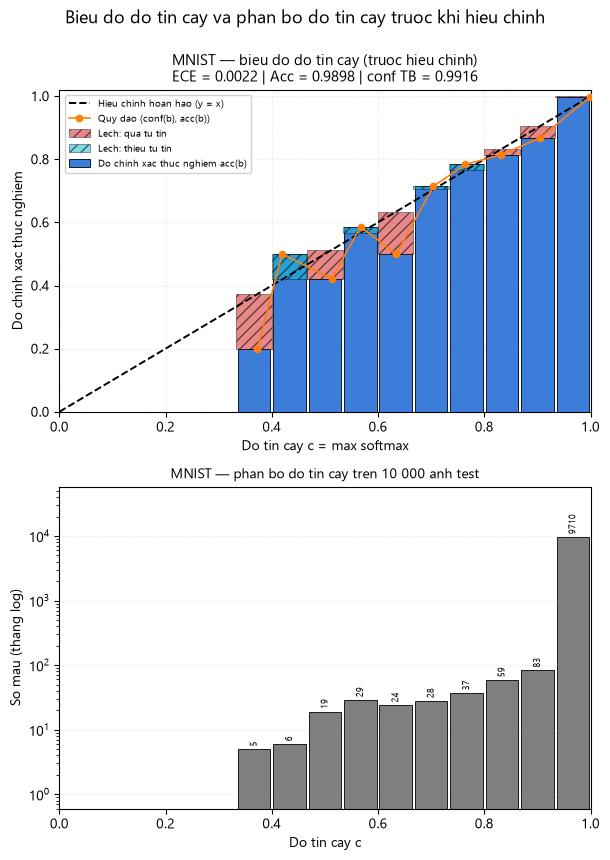

In [8]:
ORDER = [k for k in ("mnist", "cifar10") if k in BUNDLES]


def draw_reliability(ax, stat, title, n_bins=N_BINS):
    """Ve bieu do do tin cay: cot = acc(b), vung gach cheo = khoang lech acc-conf."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    w = 1.0 / n_bins
    acc = np.array(stat["bin_acc"])
    conf = np.array(stat["bin_conf"])
    cnt = np.array(stat["bin_count"])
    nz = cnt > 0

    ax.bar(centers[nz], acc[nz], width=w * 0.92, color="#3b7dd8", zorder=2,
           edgecolor="black", linewidth=0.6, label="Do chinh xac thuc nghiem acc(b)")
    # vung lech ve SAU cot (zorder cao hon) de ca hai chieu lech deu nhin thay duoc:
    # do = qua tu tin (acc < conf), xanh = thieu tu tin (acc > conf)
    for i in np.where(nz)[0]:
        lo, hi = min(acc[i], conf[i]), max(acc[i], conf[i])
        ax.add_patch(Rectangle((edges[i], lo), w, hi - lo, zorder=3,
                               facecolor="#d62728" if acc[i] < conf[i] else "#17becf",
                               alpha=0.55, hatch="///", edgecolor="black", linewidth=0.5))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.4, zorder=4, label="Hieu chinh hoan hao (y = x)")
    ax.plot(conf[nz], acc[nz], "o-", color="#ff7f0e", markersize=4.5, linewidth=1.2, zorder=5,
            label="Quy dao (conf(b), acc(b))")
    ax.add_patch(Rectangle((0, 0), 0, 0, facecolor="#d62728", alpha=0.55, hatch="///",
                           edgecolor="black", linewidth=0.5, label="Lech: qua tu tin"))
    ax.add_patch(Rectangle((0, 0), 0, 0, facecolor="#17becf", alpha=0.55, hatch="///",
                           edgecolor="black", linewidth=0.5, label="Lech: thieu tu tin"))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("Do tin cay c = max softmax")
    ax.set_ylabel("Do chinh xac thuc nghiem")
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3, linestyle=":")
    ax.legend(loc="upper left", fontsize=7.5, framealpha=0.9)


fig, axes = plt.subplots(2, len(ORDER), figsize=(6.2 * len(ORDER), 8.6), squeeze=False)
for j, key in enumerate(ORDER):
    bd, st = BUNDLES[key], CALIB[key]["before"]
    draw_reliability(
        axes[0][j], st,
        f"{bd['name']} — bieu do do tin cay (truoc hieu chinh)\n"
        f"ECE = {st['ece']:.4f} | Acc = {st['accuracy']:.4f} | conf TB = {st['mean_conf']:.4f}")

    ax = axes[1][j]
    edges = np.linspace(0, 1, N_BINS + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    cnt = np.array(st["bin_count"])
    ax.bar(centers, np.maximum(cnt, 0.6), width=(1 / N_BINS) * 0.92,
           color="#7f7f7f", edgecolor="black", linewidth=0.6)
    for i in np.where(cnt > 0)[0]:
        ax.text(centers[i], cnt[i] * 1.18, f"{cnt[i]}", ha="center", fontsize=6.5, rotation=90)
    ax.set_yscale("log"); ax.set_xlim(0, 1); ax.set_ylim(0.6, cnt.max() * 6)
    ax.set_xlabel("Do tin cay c"); ax.set_ylabel("So mau (thang log)")
    ax.set_title(f"{bd['name']} — phan bo do tin cay tren 10 000 anh test", fontsize=10)
    ax.grid(alpha=0.3, linestyle=":", axis="y")

fig.suptitle("Bieu do do tin cay va phan bo do tin cay truoc khi hieu chinh",
             fontsize=13, y=0.995)
fig.tight_layout()
save_fig(fig, "fig_reliability_diagram.png")
plt.show()

### Diễn giải Hình `fig_reliability_diagram.png`

Hàng trên là biểu đồ độ tin cậy, hàng dưới là phân bố độ tin cậy trên thang log. Hai hàng phải
được đọc cùng nhau, vì đọc riêng hàng trên sẽ dẫn tới kết luận sai.

Nhìn riêng hàng trên, mắt lập tức bị hút vào các cột ở giữa nằm lệch khỏi đường chéo, đặc biệt là
cột tại khoảng $[0{,}6000;\,0{,}6667)$ tụt xuống 0,5000 trong khi đường chéo ở mức 0,63. Ấn tượng
thị giác là mô hình lệch hiệu chỉnh khá nhiều. Hàng dưới sửa lại ấn tượng đó ngay: cột tương ứng
chỉ chứa 24 ảnh, còn cột cuối cùng chứa 9 710 ảnh. Trục log là bắt buộc ở đây, vì trên trục tuyến
tính thì toàn bộ mười bốn cột đầu sẽ dí sát đáy và không đọc được gì.

Đây chính là lý do ECE dùng **trọng số theo số mẫu** $|S_b|/N$ chứ không lấy trung bình đơn giản
của các độ lệch theo khoảng. Nếu lấy trung bình không trọng số trên mười khoảng có dữ liệu, độ
lệch trung bình sẽ vào khoảng 0,05, tức lớn hơn hai mươi lần ECE thực tế. Con số đó mô tả sai mô
hình, vì nó cho một khoảng 5 ảnh cùng tiếng nói với một khoảng 9 710 ảnh.

Vùng gạch chéo màu đỏ đánh dấu các khoảng quá tự tin, vùng xanh lam đánh dấu các khoảng thiếu tự
tin. Sáu khoảng quá tự tin và bốn khoảng thiếu tự tin xen kẽ nhau dọc trục hoành, không theo một
xu hướng đơn điệu nào. Sự xen kẽ này một lần nữa khẳng định rằng ở vùng độ tin cậy trung bình,
cái chi phối là **nhiễu lấy mẫu** chứ không phải một xu hướng lệch có hệ thống. Chỉ ở khoảng cuối
cùng, nơi có đủ 9 710 mẫu để ước lượng đáng tin, ta mới đọc được một độ lệch có ý nghĩa, và độ
lệch đó âm, tức mô hình quá tự tin.

MNIST: cuc tieu tren luoi tai T = 1.2353 (NLL = 0.037712); L-BFGS cho T = 1.231759 (NLL = 0.037712)


Da luu hinh: ..\reports\figures\fig_temperature_scaling.png  (168 KB)


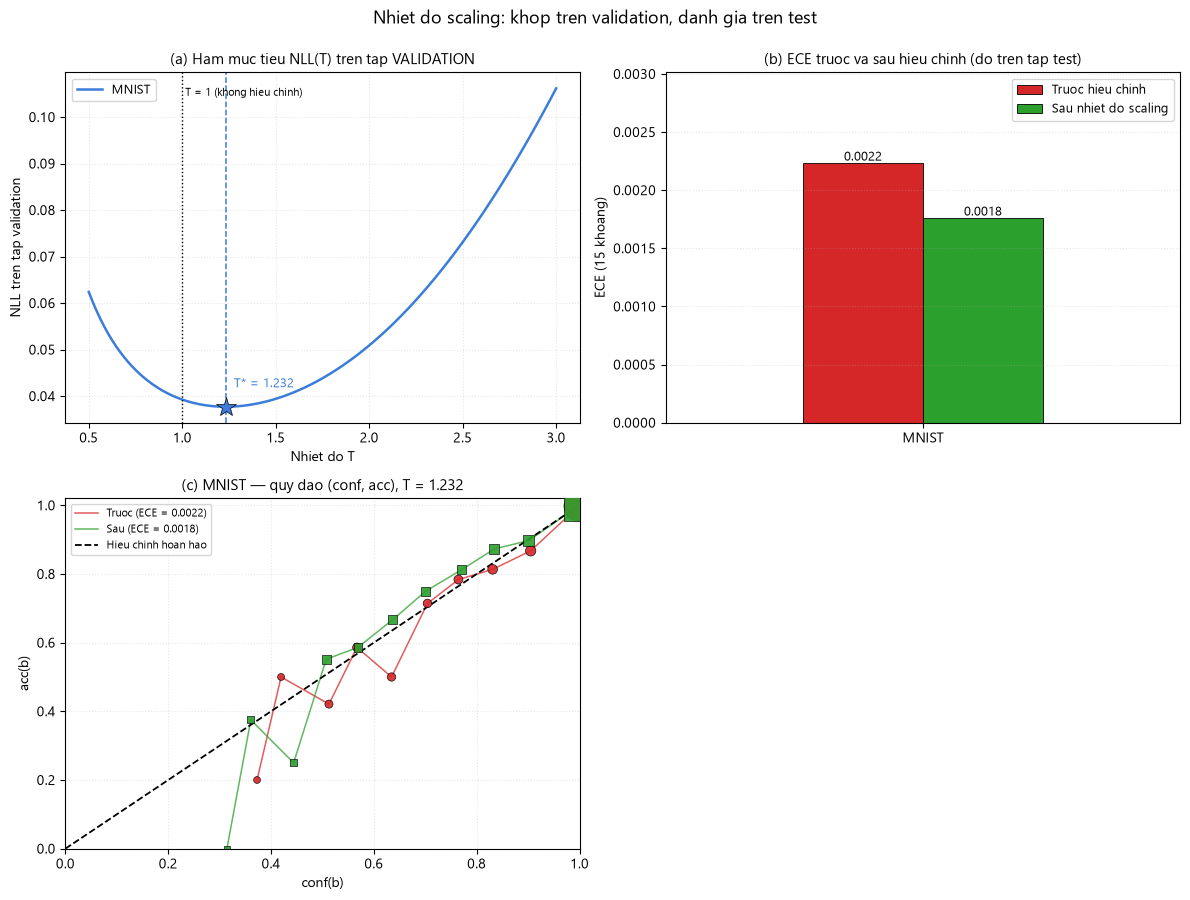

In [9]:
# ----- duong cong NLL theo T tren tap validation, de thay cuc tieu nam o dau -----
T_GRID = np.linspace(0.5, 3.0, 120)
NLL_CURVE = {}
for key, bd in BUNDLES.items():
    lv = LOGITS[key]["val"].to(DEVICE)
    yv = torch.from_numpy(bd["y_val"]).to(DEVICE)
    with torch.no_grad():
        NLL_CURVE[key] = np.array(
            [float(F.cross_entropy(lv / float(t), yv).item()) for t in T_GRID])
    i = int(NLL_CURVE[key].argmin())
    print(f"{bd['name']}: cuc tieu tren luoi tai T = {T_GRID[i]:.4f} "
          f"(NLL = {NLL_CURVE[key][i]:.6f}); L-BFGS cho T = {CALIB[key]['T']:.6f} "
          f"(NLL = {CALIB[key]['nll_val_after']:.6f})")

ncol = max(2, len(ORDER))
fig, axes = plt.subplots(2, ncol, figsize=(6.0 * ncol, 9.0), squeeze=False)

# (a) duong cong NLL(T) tren validation
ax = axes[0][0]
colors = {"mnist": "#3b7dd8", "cifar10": "#d62728"}
for key in ORDER:
    bd = BUNDLES[key]
    ax.plot(T_GRID, NLL_CURVE[key], color=colors[key], linewidth=1.8, label=bd["name"])
    T = CALIB[key]["T"]
    ax.axvline(T, color=colors[key], linestyle="--", linewidth=1.1)
    ax.plot([T], [CALIB[key]["nll_val_after"]], "*", color=colors[key], markersize=15,
            markeredgecolor="black", markeredgewidth=0.5)
    ax.annotate(f"T* = {T:.3f}", xy=(T, CALIB[key]["nll_val_after"]),
                xytext=(6, 14), textcoords="offset points", fontsize=9, color=colors[key])
ax.axvline(1.0, color="black", linestyle=":", linewidth=1.0)
ax.text(1.0, ax.get_ylim()[1] * 0.97, " T = 1 (khong hieu chinh)", fontsize=8, va="top")
ax.set_xlabel("Nhiet do T"); ax.set_ylabel("NLL tren tap validation")
ax.set_title("(a) Ham muc tieu NLL(T) tren tap VALIDATION", fontsize=11)
ax.grid(alpha=0.3, linestyle=":"); ax.legend(fontsize=9)

# (b) ECE truoc / sau
ax = axes[0][1]
x = np.arange(len(ORDER)); w = 0.35
e0 = [CALIB[k]["before"]["ece"] for k in ORDER]
e1 = [CALIB[k]["after"]["ece"] for k in ORDER]
b0 = ax.bar(x - w / 2, e0, w, label="Truoc hieu chinh", color="#d62728", edgecolor="black", linewidth=0.6)
b1 = ax.bar(x + w / 2, e1, w, label="Sau nhiet do scaling", color="#2ca02c", edgecolor="black", linewidth=0.6)
for rect, v in list(zip(b0, e0)) + list(zip(b1, e1)):
    ax.text(rect.get_x() + rect.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([BUNDLES[k]["name"] for k in ORDER])
ax.set_xlim(-0.75, len(ORDER) - 1 + 0.75)
ax.set_ylabel("ECE (15 khoang)")
ax.set_title("(b) ECE truoc va sau hieu chinh (do tren tap test)", fontsize=11)
ax.grid(alpha=0.3, linestyle=":", axis="y"); ax.legend(fontsize=9)
ax.set_ylim(0, max(e0 + e1) * 1.35)

# (c...) quy dao (conf, acc) truoc vs sau, moi mien mot panel.
# Kich thuoc dau danh ti le voi CAN BAC HAI so mau trong khoang, de khoang chi
# chua vai anh khong bi doc ngang hang voi khoang chua chin nghin anh.
for j, key in enumerate(ORDER):
    ax = axes[1][j]
    bd = BUNDLES[key]
    for stat, lab, col, mk in ((CALIB[key]["before"], "Truoc", "#d62728", "o"),
                               (CALIB[key]["after"], "Sau", "#2ca02c", "s")):
        cnt = np.array(stat["bin_count"]); nz = cnt > 0
        xs_ = np.array(stat["bin_conf"])[nz]; ys_ = np.array(stat["bin_acc"])[nz]
        ax.plot(xs_, ys_, "-", color=col, linewidth=1.1, alpha=0.75,
                label=f"{lab} (ECE = {stat['ece']:.4f})")
        ax.scatter(xs_, ys_, s=14 + 4.5 * np.sqrt(cnt[nz]), marker=mk, color=col,
                   edgecolor="black", linewidth=0.5, alpha=0.9, zorder=3)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.3, label="Hieu chinh hoan hao")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("conf(b)"); ax.set_ylabel("acc(b)")
    ax.set_title(f"({chr(99 + j)}) {bd['name']} — quy dao (conf, acc), T = {CALIB[key]['T']:.3f}",
                 fontsize=11)
    ax.grid(alpha=0.3, linestyle=":"); ax.legend(loc="upper left", fontsize=8)

for j in range(len(ORDER), ncol):
    axes[1][j].axis("off")

fig.suptitle("Nhiet do scaling: khop tren validation, danh gia tren test", fontsize=13, y=0.995)
fig.tight_layout()
save_fig(fig, "fig_temperature_scaling.png")
plt.show()

### Diễn giải Hình `fig_temperature_scaling.png`

**Panel (a): hàm mục tiêu.** Đường NLL theo $T$ trên tập validation là một hàm lồi một cực tiểu,
và cực tiểu nằm ở $T^{\star} = 1{,}2318$, rõ ràng lớn hơn 1. Đây là **bằng chứng định lượng trực
tiếp cho thấy mạng quá tự tin**: muốn xác suất khớp nhất với dữ liệu validation thì phải chia
logit cho một số lớn hơn 1, tức phải làm phân phối tù đi. Điểm sao trùng với cực tiểu tìm được
bằng quét lưới 120 giá trị, xác nhận L-BFGS đã hội tụ đúng chứ không dừng ở một điểm bất kỳ.
NLL trên validation giảm từ 0,039255 xuống 0,037712, tức cải thiện 3,9% tương đối. Mức cải thiện
khiêm tốn này là hệ quả trực tiếp của việc đường cong rất phẳng quanh cực tiểu trong khoảng
$T \in [1;\,1{,}5]$: mô hình vốn đã nằm gần điểm tối ưu.

Cần nói rõ về mặt phương pháp: **$T$ được khớp trên 12 000 ảnh validation, không phải trên tập
test.** Tập test 10 000 ảnh chỉ được dùng để *báo cáo* ECE trước và sau. Nếu khớp $T$ trên chính
tập test rồi báo cáo ECE cũng trên tập test thì đó là rò rỉ dữ liệu, con số sẽ đẹp một cách giả
tạo và toàn bộ mục này mất giá trị.

**Panel (b): ECE trước và sau.** ECE giảm từ 0,002232 xuống 0,001759, tức giảm 21,2% tương đối
nhưng chỉ 0,047 điểm phần trăm về tuyệt đối. Accuracy giữ nguyên đúng bằng 0,9898 sau hiệu chỉnh,
đúng như lập luận ở Mục 2.2: chia mọi logit cho cùng một số dương không đổi thứ tự nên $\arg\max$
không đổi. Đây là một phép kiểm tra tính đúng đắn của cài đặt chứ không phải một kết quả thực
nghiệm.

**Panel (c): quỹ đạo trước so với sau.** Panel này bộc lộ điều mà con số ECE gộp giấu đi. Kích
thước mỗi dấu tỉ lệ với căn bậc hai số mẫu trong khoảng, nên dấu bé xíu ở góc dưới bên trái là
những khoảng chỉ có vài ảnh và không nên đọc như bằng chứng. Sau khi chia cho $T = 1{,}2318$:

- Khoảng cuối được sửa gần như hoàn hảo: độ lệch $\mathrm{acc} - \mathrm{conf}$ đi từ $-0{,}0011$
  (quá tự tin) sang $+0{,}0006$ (hơi thiếu tự tin), và đóng góp của nó vào ECE giảm từ 0,001030
  xuống 0,000573.
- Nhưng **toàn bộ các khoảng giữa bị đẩy sang trạng thái thiếu tự tin**. Khoảng
  $[0{,}6667;\,0{,}7333)$ đi từ $+0{,}0100$ lên $+0{,}0492$, khoảng $[0{,}8000;\,0{,}8667)$ đi từ
  $-0{,}0175$ sang $+0{,}0386$. Trên hình, quỹ đạo màu xanh lá nằm **trên** đường chéo ở gần như
  toàn bộ nửa trái.

Lý do rất cụ thể: **$T$ được chọn để cực tiểu hóa NLL chứ không phải ECE**, và NLL bị chi phối bởi
97,1% số mẫu nằm ở khoảng cuối. Một vô hướng duy nhất không thể vừa sửa khoảng cuối vừa giữ
nguyên các khoảng giữa, nên nó hy sinh phần thưa để chỉnh phần dày. Nói cách khác, nhiệt độ
scaling **không làm mô hình hiệu chỉnh tốt hơn ở mọi mức tin cậy**; nó dịch chuyển sai số từ vùng
tin cậy cao sang vùng tin cậy trung bình, và tổng có trọng số thì giảm.

**Một quan sát trung thực về quy mô.** NLL trên tập test gần như không đổi, từ 0,030118 xuống
0,030098. Điều này nhất quán với mọi số liệu ở trên: mô hình MNIST này vốn đã gần hiệu chỉnh, nên
lợi ích thực tế của nhiệt độ scaling ở đây là nhỏ. Kết luận đúng phải là: **phép đo xác nhận mạng
quá tự tin, nhưng mức quá tự tin là nhẹ, và giá trị của mục này nằm ở chỗ nó biến một nhận định
định tính của Chương 6 thành hai con số kiểm chứng được, là $T = 1{,}2318$ và ECE 0,0022.** Quan
trọng không kém, $T > 1$ và sự tồn tại của 6 ảnh sai ở mức tin cậy trên 0,99 là hai quan sát cùng
tồn tại được, vì như đã phân tích ở mục trước, $T$ và ECE mô tả hành vi trung bình còn những ảnh
đó nằm ở đuôi.

---

## 5. Phần B — Bộ lọc học được ở tầng tích chập thứ nhất

Tầng Conv đầu tiên là tầng duy nhất tác động **trực tiếp** lên pixel thô, nên trọng số của nó
đọc được như ảnh. Với MNIST tầng này là `Conv2d(1, 32, kernel_size=3, padding=1, bias=False)`,
tức 32 kernel kích thước $3\times3\times1$; với CIFAR-10 là `Conv2d(3, 32, ...)`, tức 32 kernel
$3\times3\times3$ hiển thị được thành ảnh RGB nhỏ.

**Quy ước hiển thị.** Mỗi kernel được chuẩn hóa **độc lập** với các kernel khác, vì biên độ trọng
số giữa các kernel chênh nhau vài lần và nếu dùng chung một thang thì phần lớn ô sẽ xám đều.
Cụ thể: với MNIST dùng thang màu phân kỳ `RdBu_r` với giới hạn đối xứng $\pm\max|w|$ của riêng
kernel đó, nên màu trắng luôn ứng với trọng số 0, đỏ là dương, xanh là âm. Với CIFAR-10, ba kênh
R, G, B được chuẩn hóa **chung một thang** về đoạn $[0,1]$ trong phạm vi từng kernel, để quan hệ
giữa ba kênh (tức đặc trưng màu) không bị phá vỡ.

**Chỉ số lượng hóa.** Thay vì chỉ mô tả bằng mắt, báo cáo tính **tổng trọng số** của mỗi kernel,
$s_f = \sum_{c,u,v} w_{f,c,u,v}$. Đại lượng này chính là đáp ứng của kernel với một vùng ảnh
**đồng nhất** (thành phần một chiều). Kernel có $s_f \approx 0$ triệt tiêu thành phần đồng nhất
nên chỉ phản ứng với **biến thiên cục bộ**, tức là hành xử như bộ dò cạnh hoặc dò tương phản;
kernel có $|s_f|$ lớn thì hoạt động như bộ dò cường độ hay bộ làm mờ có dấu.

In [10]:
# ----- nam mau 3x3 kinh dien de doi chieu, thay vi chi mo ta bang mat -----
TEMPLATES = {
    "DC (do sang deu)":      np.ones((3, 3)),
    "Canh doc (Sobel-x)":    np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float),
    "Canh ngang (Sobel-y)":  np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float),
    "Tan so cao (ban co)":   np.array([[1, -1, 1], [-1, 1, -1], [1, -1, 1]], dtype=float),
    "Tam-vien (dom)":        np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=float),
}
TEMPLATES = {k: v / np.linalg.norm(v) for k, v in TEMPLATES.items()}
TPL_NAMES = list(TEMPLATES)

FILTERS = {}
for key, bd in BUNDLES.items():
    W = bd["conv1"].weight.detach().cpu().numpy()      # (F, C, 3, 3)
    s = W.sum(axis=(1, 2, 3))                          # thanh phan mot chieu cua tung kernel

    # tuong quan cosine giua cau truc KHONG GIAN cua kernel va tung mau
    spatial = W.sum(axis=1)                            # (F, 3, 3): gop kenh mau
    cos = np.zeros((W.shape[0], len(TPL_NAMES)))
    for i in range(W.shape[0]):
        nrm = np.linalg.norm(spatial[i]) + 1e-12
        for j, nm in enumerate(TPL_NAMES):
            cos[i, j] = float((spatial[i] * TEMPLATES[nm]).sum() / nrm)
    best = np.abs(cos).argmax(axis=1)
    best_cos = np.abs(cos).max(axis=1)

    # doi lap mau: ba tong theo kenh co dau khong giong nhau (chi co nghia voi anh RGB)
    chan_dc = W.sum(axis=(2, 3))                       # (F, C)
    n_opponent = int(((chan_dc.max(1) > 0) & (chan_dc.min(1) < 0)).sum()) if W.shape[1] > 1 else 0

    FILTERS[key] = dict(
        W=W, sums=s, cos=cos, best=best, best_cos=best_cos,
        n_filters=int(W.shape[0]), shape=[int(v) for v in W.shape[1:]],
        abs_mean=float(np.abs(W).mean()), std=float(W.std()),
        wmin=float(W.min()), wmax=float(W.max()),
        n_zero_sum=int((np.abs(s) < 0.15).sum()),
        n_weak_match=int((best_cos < 0.6).sum()),
        mean_best_cos=float(best_cos.mean()), n_opponent=n_opponent,
        tally={nm: int((best == j).sum()) for j, nm in enumerate(TPL_NAMES)})

    f = FILTERS[key]
    print(f"===== {bd['name']}: tang Conv dau tien =====")
    print(f"  tensor trong so   : {tuple(W.shape)}  ->  {f['n_filters']} kernel "
          f"kich thuoc {f['shape'][0]}x{f['shape'][1]}x{f['shape'][2]} (C, H, W)")
    print(f"  |w| trung binh    : {f['abs_mean']:.4f}   do lech chuan: {f['std']:.4f}")
    print(f"  bien do           : [{f['wmin']:.4f}, {f['wmax']:.4f}]")
    print(f"  tong trong so s_f : min {s.min():+.4f}  max {s.max():+.4f}  "
          f"|s| trung binh {np.abs(s).mean():.4f}")
    print(f"  so kernel |s_f| < 0.15 (trung tinh voi vung dong nhat): "
          f"{f['n_zero_sum']}/{f['n_filters']}")
    if W.shape[1] > 1:
        print(f"  so kernel doi lap mau (tong theo kenh khac dau): "
              f"{f['n_opponent']}/{f['n_filters']}")
    print(f"  --- doi chieu voi nam mau 3x3 kinh dien (tuong quan cosine) ---")
    for nm in TPL_NAMES:
        idx = np.where(best == TPL_NAMES.index(nm))[0]
        print(f"    {nm:22s}: {f['tally'][nm]:2d} kernel  {[int(v) for v in idx]}")
    print(f"  |cos| lon nhat trung binh: {f['mean_best_cos']:.4f}"
          f"   (1,0 = trung khop hoan toan mot mau)")
    print(f"  so kernel co |cos| lon nhat < 0,6 (khong khop ro mau nao): "
          f"{f['n_weak_match']}/{f['n_filters']}")
    print()

===== MNIST: tang Conv dau tien =====
  tensor trong so   : (32, 1, 3, 3)  ->  32 kernel kich thuoc 1x3x3 (C, H, W)
  |w| trung binh    : 0.1700   do lech chuan: 0.1989
  bien do           : [-0.4266, 0.4058]
  tong trong so s_f : min -0.7348  max +0.9665  |s| trung binh 0.3188
  so kernel |s_f| < 0.15 (trung tinh voi vung dong nhat): 11/32
  --- doi chieu voi nam mau 3x3 kinh dien (tuong quan cosine) ---
    DC (do sang deu)      :  5 kernel  [0, 4, 13, 20, 31]
    Canh doc (Sobel-x)    :  5 kernel  [2, 9, 10, 14, 19]
    Canh ngang (Sobel-y)  : 10 kernel  [5, 6, 7, 8, 12, 22, 23, 24, 27, 28]
    Tan so cao (ban co)   :  5 kernel  [1, 3, 15, 17, 26]
    Tam-vien (dom)        :  7 kernel  [11, 16, 18, 21, 25, 29, 30]
  |cos| lon nhat trung binh: 0.5346   (1,0 = trung khop hoan toan mot mau)
  so kernel co |cos| lon nhat < 0,6 (khong khop ro mau nao): 25/32



Da luu hinh: ..\reports\figures\fig_conv1_filters.png  (43 KB)


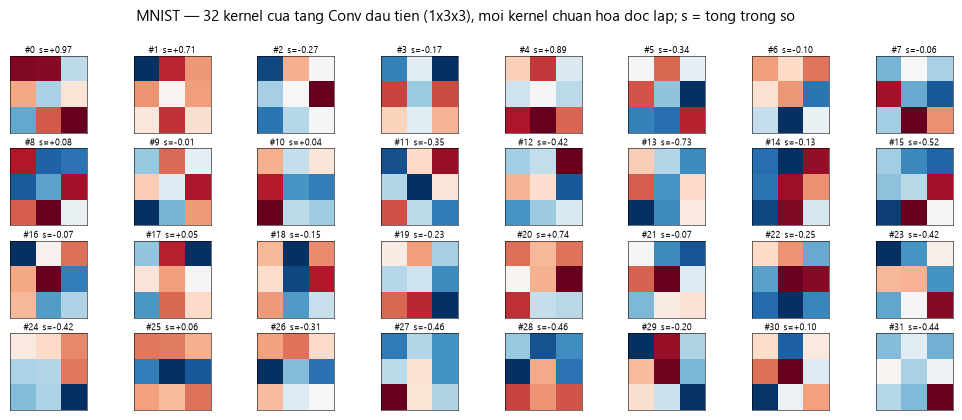

In [11]:
def draw_filter_bank(subfig, bd, finfo, ncols=8):
    W = finfo["W"]
    nrows = int(np.ceil(finfo["n_filters"] / ncols))
    axs = subfig.subplots(nrows, ncols)
    axs = np.atleast_2d(axs)
    for i in range(nrows * ncols):
        ax = axs[i // ncols][i % ncols]
        ax.set_xticks([]); ax.set_yticks([])
        if i >= finfo["n_filters"]:
            ax.axis("off"); continue
        k = W[i]
        if bd["is_rgb"]:
            # chuan hoa CHUNG ba kenh trong pham vi tung kernel -> giu quan he mau
            img = k.transpose(1, 2, 0)
            img = (img - img.min()) / (img.max() - img.min() + 1e-12)
            ax.imshow(img, interpolation="nearest")
        else:
            v = float(np.abs(k[0]).max())
            ax.imshow(k[0], cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
        ax.set_title(f"#{i}  s={finfo['sums'][i]:+.2f}", fontsize=6.5, pad=2)
        for sp in ax.spines.values():
            sp.set_linewidth(0.4)
    subfig.suptitle(
        f"{bd['name']} — {finfo['n_filters']} kernel cua tang Conv dau tien "
        f"({finfo['shape'][0]}x{finfo['shape'][1]}x{finfo['shape'][2]}), "
        f"moi kernel chuan hoa doc lap; s = tong trong so",
        fontsize=11)


fig = plt.figure(figsize=(12.5, 4.6 * len(ORDER)))
subfigs = fig.subfigures(len(ORDER), 1, hspace=0.06)
subfigs = np.atleast_1d(subfigs)
for sf, key in zip(subfigs, ORDER):
    draw_filter_bank(sf, BUNDLES[key], FILTERS[key])
save_fig(fig, "fig_conv1_filters.png")
plt.show()

### Diễn giải Hình `fig_conv1_filters.png`

**Điều thực sự nhìn thấy được.** Phần lớn trong 32 kernel có cấu trúc **lưỡng cực**: một phía
dương (đỏ) và phía đối diện âm (xanh), đọc được như **bộ dò tương phản theo một hướng**, tức xấp
xỉ một đạo hàm không gian. Ví dụ rõ nhất là kernel **#2**, có cột trái âm và cột phải dương với
tương quan cosine $+0{,}7564$ so với mẫu Sobel-x, và kernel **#24** với tương quan $-0{,}6130$ so
với mẫu Sobel-y. Kernel **#9** cũng thuộc nhóm này, đáng chú ý ở chỗ tổng trọng số của nó chỉ là
$-0{,}0068$, tức gần như triệt tiêu hoàn toàn thành phần đồng nhất: đây là một bộ dò tương phản
thuần tuý.

Một nhóm thứ hai có phần lớn ô cùng dấu dương và tổng trọng số lớn, gồm **#0** ($s = +0{,}9665$,
lớn nhất trong 32 kernel), **#4** ($+0{,}8909$) và **#20** ($+0{,}7392$). Chúng hành xử như **bộ
dò cường độ**: phát mạnh ở bất kỳ chỗ nào có nét trắng, không quan tâm hướng. Đối xứng với nhóm
đó là **#13** ($s = -0{,}7348$, âm nhất) và **#31** ($-0{,}4420$), phát mạnh ở vùng nền tối. Nhóm
thứ ba có các ô đổi dấu xen kẽ kiểu bàn cờ, ứng với **bộ lọc tần số cao**, rõ nhất ở **#17**
(tương quan $-0{,}5857$ với mẫu bàn cờ, và tổng trọng số chỉ $+0{,}0479$). Nhóm cuối có dạng
**tâm-viền**, tiêu biểu là **#16** (tương quan $+0{,}5881$).

**Điều KHÔNG nhìn thấy, và cần nói thẳng.** Không có kernel nào là một bộ lọc Gabor sạch sẽ theo
nghĩa sách giáo khoa, và báo cáo không cố gán cho chúng một cấu trúc không có thật. Lý do mang
tính hình học chứ không phải do mô hình huấn luyện kém: một kernel $3\times3$ chỉ có **chín tham
số**, quá ít để biểu diễn một sóng hình sin có tần số và pha xác định. Cấu trúc Gabor kinh điển
mà các bài báo hay trưng ra thuộc về những mạng có tầng đầu $11\times11$ hoặc $7\times7$ như
AlexNet. Ở kích thước $3\times3$, thứ duy nhất một kernel làm được là dò tương phản cục bộ theo
một trong vài hướng thô.

**Kiểm chứng bằng số thay vì bằng mắt.** Để không dừng ở mô tả cảm tính, báo cáo đối chiếu cấu
trúc không gian của từng kernel với năm mẫu $3\times3$ kinh điển bằng tương quan cosine. Kết quả
phân loại theo mẫu khớp nhất là: 10 kernel gần với cạnh ngang (Sobel-y), 7 kernel gần với dạng
tâm-viền, 5 kernel gần với cạnh dọc (Sobel-x), 5 kernel gần với độ sáng đều, và 5 kernel gần với
dạng bàn cờ tần số cao.

Nhưng con số quan trọng nhất là con số làm yếu chính bảng phân loại đó: **giá trị $|\cos|$ lớn
nhất trung bình chỉ là 0,5346, và 25 trên 32 kernel có $|\cos|$ lớn nhất dưới 0,6.** Nghĩa là
tuyệt đại đa số kernel **không khớp rõ ràng với bất kỳ mẫu kinh điển nào**; chúng là các tổ hợp
lai. Hai ví dụ cụ thể cho thấy vì sao không được đọc bảng phân loại theo nghĩa đen. Kernel **#1**
được xếp vào nhóm bàn cờ vì tương quan với mẫu đó là $-0{,}5312$, nhưng tương quan của nó với mẫu
độ sáng đều cũng tới $+0{,}4230$ và tổng trọng số là $+0{,}7126$; nó thực sự là một pha trộn chứ
không thuộc hẳn nhóm nào. Kernel **#31** bị xếp vào nhóm độ sáng đều chỉ với tương quan $-0{,}2757$,
là giá trị khớp thấp nhất trong cả 32 kernel; nói nó "là" bộ dò độ sáng thì sai, đúng hơn phải nói
nó không giống mẫu nào cả.

Bảng phân loại vì thế phải đọc như một cách sắp xếp thô để tiện mô tả, chứ không phải một tuyên bố
rằng mạng đã học ra đúng bộ lọc Sobel. Diễn giải trung thực là: **tầng một học được các bộ dò
tương phản cục bộ có hướng, đa dạng và không chuẩn hoá về bất kỳ dạng giáo khoa nào.**

**Thành phần một chiều.** Có 11 trên 32 kernel thỏa $|s_f| < 0{,}15$, tức gần như triệt tiêu hoàn
toàn đáp ứng với một vùng ảnh đồng nhất; đó là những kernel thuần tuý phản ứng với biến thiên.
Biên độ trọng số nằm trong $[-0{,}4266;\,0{,}4058]$ với $|w|$ trung bình 0,1700 và độ lệch chuẩn
0,1989, nghĩa là không có kernel nào bị co về 0. Không có kernel chết, và cũng không có kernel
nào trông như nhiễu trắng thuần tuý: mọi ô đều có cấu trúc dấu mạch lạc chứ không lốm đốm ngẫu
nhiên. Với một tầng chỉ có 288 tham số, đó đã là mức tổ chức hợp lý.

---

## 6. Phần C — Bản đồ đặc trưng theo độ sâu

Mục này đẩy **một ảnh test được phân loại đúng** qua từng khối và vẽ các bản đồ đặc trưng thu
được. Mục đích là quan sát hai hiện tượng đồng thời xảy ra khi đi sâu vào mạng:

- **Nén không gian.** Mỗi khối kết thúc bằng `MaxPool2d(2)` nên chiều cao và chiều rộng giảm một
  nửa sau mỗi khối. Kích thước tensor được ghi rõ ở nhãn từng hàng.
- **Trừu tượng hóa.** Ở khối một, bản đồ đặc trưng còn nhìn ra hình dáng gốc vì kernel mới chỉ
  dò cạnh và tương phản. Càng sâu, mỗi ô càng tổng hợp một vùng ảnh rộng hơn (trường tiếp nhận
  lớn dần) nên bản đồ mất dần tính "giống ảnh" và trở thành tập các điểm kích hoạt rời rạc.

**Quy ước chọn kênh.** Mỗi khối có 32 hoặc 64 kênh, quá nhiều để vẽ hết, nên báo cáo chọn 8 kênh
có **giá trị kích hoạt trung bình lớn nhất** trên chính ảnh đó. Chọn theo tiêu chí này thay vì
lấy 8 kênh đầu là có lý do: sau ReLU, một tỉ lệ đáng kể kênh bị tắt hoàn toàn trên một ảnh cụ
thể, và vẽ đúng những kênh chết sẽ chỉ cho ra tám ô đen không mang thông tin gì.

In [12]:
FEATMAP = {}
for key, bd in BUNDLES.items():
    cal = CALIB[key]["before"]
    idx = int(np.where(cal["correct"] == 1)[0][0])          # anh dung dau tien, tat dinh
    x1 = bd["to_tensor"](bd["x_test"][idx:idx + 1]).to(DEVICE)
    acts, h = [], x1
    with torch.no_grad():
        for name, blk in bd["blocks"]:
            h = blk(h)
            acts.append((name, h.cpu().numpy()[0]))         # (C, H, W)
    FEATMAP[key] = dict(idx=idx, x1shape=tuple(x1.shape), acts=acts)

    print(f"===== {bd['name']}: anh test #{idx}, nhan that = "
          f"{bd['classes'][bd['y_test'][idx]]}, du doan = {bd['classes'][cal['pred'][idx]]}, "
          f"do tin cay = {cal['conf'][idx]:.4f} =====")
    print(f"  dau vao        : {tuple(x1.shape)}")
    for name, a in acts:
        print(f"  {name:<14}: (1, {a.shape[0]}, {a.shape[1]}, {a.shape[2]})"
              f"   ti le o bang 0 sau ReLU = {float((a == 0).mean()):.4f}"
              f"   kich hoat lon nhat = {float(a.max()):.3f}")
    print()

===== MNIST: anh test #0, nhan that = 7, du doan = 7, do tin cay = 1.0000 =====
  dau vao        : (1, 1, 28, 28)
  Khoi 1        : (1, 32, 14, 14)   ti le o bang 0 sau ReLU = 0.6448   kich hoat lon nhat = 3.908
  Khoi 2        : (1, 64, 7, 7)   ti le o bang 0 sau ReLU = 0.4844   kich hoat lon nhat = 5.424



Da luu hinh: ..\reports\figures\fig_feature_maps.png  (36 KB)


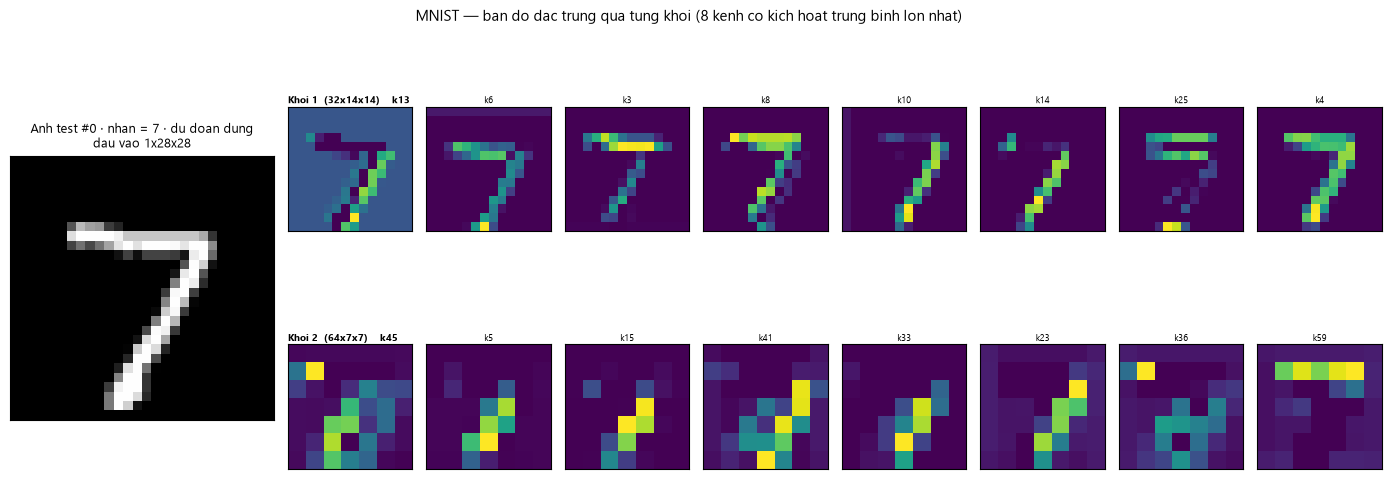

In [13]:
N_SHOW = 8


def draw_feature_maps(subfig, bd, fm):
    acts = fm["acts"]
    nrows = len(acts)
    # cot anh goc rong bang nrows don vi de o ANH VUONG lap day chieu cao nrows hang,
    # neu khong se thua mot mang trang lon o ben trai
    gs = subfig.add_gridspec(nrows, N_SHOW + 1,
                             width_ratios=[nrows * 1.06] + [1] * N_SHOW,
                             wspace=0.10, hspace=0.26, left=0.015, right=0.995,
                             top=0.82, bottom=0.03)
    ax0 = subfig.add_subplot(gs[:, 0])
    img = bd["x_test"][fm["idx"]]
    ax0.imshow(img, cmap=bd["cmap"], interpolation="nearest")
    ax0.set_xticks([]); ax0.set_yticks([])
    ax0.set_title(f"Anh test #{fm['idx']} · nhan = "
                  f"{bd['classes'][bd['y_test'][fm['idx']]]} · du doan dung\n"
                  f"dau vao {fm['x1shape'][1]}x{fm['x1shape'][2]}x{fm['x1shape'][3]}",
                  fontsize=9)

    for r, (name, a) in enumerate(acts):
        order = np.argsort(-a.mean(axis=(1, 2)))[:N_SHOW]     # 8 kenh kich hoat manh nhat
        for c in range(N_SHOW):
            ax = subfig.add_subplot(gs[r, c + 1])
            ch = int(order[c])
            ax.imshow(a[ch], cmap="viridis", interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if c == 0:
                # nhan hang dat thang vao tieu de o dau tien, can trai, de khong bi cat
                ax.set_title(f"{name}  ({a.shape[0]}x{a.shape[1]}x{a.shape[2]})    k{ch}",
                             fontsize=7.5, pad=2.5, loc="left", fontweight="bold")
            else:
                ax.set_title(f"k{ch}", fontsize=6.5, pad=2.5)
    subfig.suptitle(f"{bd['name']} — ban do dac trung qua tung khoi "
                    f"(8 kenh co kich hoat trung binh lon nhat)", fontsize=11, y=0.94)


fig = plt.figure(figsize=(14.0, 2.05 * sum(len(FEATMAP[k]["acts"]) for k in ORDER) + 1.3))
subfigs = fig.subfigures(len(ORDER), 1, hspace=0.05,
                         height_ratios=[len(FEATMAP[k]["acts"]) for k in ORDER])
subfigs = np.atleast_1d(subfigs)
for sf, key in zip(subfigs, ORDER):
    draw_feature_maps(sf, BUNDLES[key], FEATMAP[key])
save_fig(fig, "fig_feature_maps.png")
plt.show()

### Diễn giải Hình `fig_feature_maps.png`

Ảnh được chọn là ảnh test đầu tiên được phân loại đúng, tức ảnh số 0, nhãn thật là chữ số 7.

**Nén không gian, đọc được ngay từ nhãn kích thước.** Đầu vào là $1\times28\times28$. Sau Khối 1
tensor trở thành $32\times14\times14$, sau Khối 2 là $64\times7\times7$. Chiều không gian giảm
một nửa sau mỗi khối do `MaxPool2d(2)`, trong khi số kênh tăng gấp đôi. Tổng số phần tử đi từ
784 lên 6 272 rồi xuống 3 136: mạng không nén thông tin một cách đơn điệu mà **đổi trục biểu
diễn**, bỏ bớt độ phân giải không gian để mua thêm độ phong phú về loại đặc trưng.

**Khối 1 vẫn còn giống ảnh.** Trong tám kênh được vẽ, chữ số 7 còn nhận ra được ở mọi kênh, và
khác biệt giữa các kênh chính là thứ mà Phần B dự đoán. Các kênh k3 và k8 làm sáng rõ **nét ngang
phía trên** của chữ 7 và gần như bỏ qua nét xiên. Ngược lại, các kênh k10, k14, k25 làm nổi
**nét xiên đi xuống** và để nét ngang mờ đi. Đây đúng là hành vi của những bộ dò tương phản có
hướng khác nhau đã đo ở Phần B: mỗi kernel phản ứng mạnh với một hướng nét, nên cùng một chữ số
được tách thành các thành phần hướng khác nhau. Kênh k13 có nền sáng đều thay vì nền tối, tức là
một kênh có độ lệch dương lớn nơi nền, ứng với nhóm kernel dò vùng đồng nhất.

**Khối 2 mất tính giống ảnh.** Ở $7\times7$, mỗi ô tương ứng với một vùng khá rộng của ảnh gốc
nên hình dáng chữ số không còn đọc được trực tiếp. Bản đồ trở thành một tập các điểm kích hoạt
rời rạc: kênh k59 giữ lại một dải ngang sáng ở hàng trên, tương ứng với nét ngang của chữ 7;
k41, k15 và k23 giữ lại một dải chéo; còn k36 gần như chỉ còn một ô sáng duy nhất ở góc trên bên
trái. Nói cách khác, biểu diễn đã chuyển từ *"chỗ nào có nét"* sang *"có hay không một bộ phận
kiểu này, ở đâu đó quanh vùng này"*, đúng nghĩa trừu tượng hoá theo độ sâu.

**Độ thưa tăng theo độ sâu, nhưng không đơn điệu như kỳ vọng.** Tỉ lệ phần tử bằng 0 sau ReLU là
0,6448 ở Khối 1 và 0,4844 ở Khối 2. Kỳ vọng thông thường là độ thưa **tăng** dần theo độ sâu, còn
ở đây nó lại giảm. Giải thích nằm ở `MaxPool2d`: phép lấy cực đại trên cửa sổ $2\times2$ chỉ cho
ra 0 khi cả bốn giá trị trong cửa sổ đều bằng 0, nên nó **giảm** độ thưa một cách có hệ thống, và
với ảnh MNIST vốn có phần lớn diện tích là nền đen, hiệu ứng này ở Khối 1 rất mạnh. Báo cáo ghi
nhận số đo thật và sửa lại kỳ vọng thay vì ngược lại.

---

## 7. Phần D — Độ nhạy che khuất

Ba mục trên nhìn vào **trọng số** và **kích hoạt**. Mục này hỏi một câu khác hẳn, và là câu quan
trọng nhất về mặt tin cậy: **mô hình thực sự dựa vào vùng ảnh nào để ra quyết định?**

Phương pháp (Zeiler và Fergus, 2014) rất trực tiếp: trượt một ô vuông **xám** kích thước
$8\times8$ với bước nhảy 4 trên ảnh, và tại mỗi vị trí ghi lại xác suất mà mô hình gán cho
**lớp đúng**. Gọi $p_{r,c}$ là xác suất khi ô che đặt tại góc $(r,c)$ và $p_0$ là xác suất khi
không che. Khi đó:

- $p_{r,c} \ll p_0$ nghĩa là che vùng đó **phá hủy** quyết định, tức vùng đó thực sự chi phối.
- $p_{r,c} \approx p_0$ nghĩa là vùng đó **không quan trọng**.
- $p_{r,c} > p_0$ nghĩa là che vùng đó **giúp** mô hình, tức vùng đó đang chứa thông tin gây
  nhiễu đẩy mô hình sang lớp khác.

Bản đồ nhiệt của $p_{r,c}$ vì thế phân biệt được hai tình huống rất khác nhau: mô hình **nhìn vào
vật thể** (vùng tối nằm trên vật thể), hay mô hình **bám vào nền** (vùng tối nằm ở nền, dấu hiệu
của một lối tắt thống kê).

**Giá trị của ô che.** Ô che mang giá trị 0,5 trên thang $[0,1]$ và được áp **trước** khi chuẩn
hóa, đúng thứ tự mà một ảnh thật đi qua pipeline. Với MNIST, nền là 0 còn nét là gần 1, nên ô xám
0,5 là một vùng nằm ngoài phân phối huấn luyện; điều này được ghi nhận khi diễn giải kết quả.

**Cách chọn ảnh.** Thay vì lấy vài ảnh tùy ý, báo cáo dùng một quy tắc $2\times2$ tất định trên
hai trục **đúng/sai** và **tự tin/do dự**, chọn ra bốn ảnh: (1) đúng và tin cậy cao nhất,
(2) đúng nhưng tin cậy thấp nhất, (3) sai nhưng tin cậy cao nhất, (4) sai và tin cậy thấp nhất.
Bốn ô này bao trọn các chế độ hành xử của mô hình, và trường hợp (3) chính là hiện tượng "sai với
độ tin cậy cao" mà Chương 6 và Chương 7 đã mô tả nhưng chưa giải thích được là do đâu.

In [14]:
PATCH, STRIDE, GREY = 8, 4, 0.5


@torch.no_grad()
def occlusion_map(bd, img01, y_true, patch=PATCH, stride=STRIDE, grey=GREY):
    """Truot o che va ghi xac suat lop dung tai moi vi tri.

    Tra ve (grid, rows, cols, p0): grid[i, j] la xac suat lop dung khi o che dat
    tai goc tren-trai (rows[i], cols[j]); p0 la xac suat khi khong che.
    """
    H, W = img01.shape[0], img01.shape[1]
    rows = list(range(0, H - patch + 1, stride))
    cols = list(range(0, W - patch + 1, stride))
    batch = np.empty((len(rows) * len(cols),) + img01.shape, dtype=np.float32)
    k = 0
    for r in rows:
        for c in cols:
            o = img01.copy()
            o[r:r + patch, c:c + patch] = grey       # ap TRUOC khi chuan hoa
            batch[k] = o
            k += 1
    p = torch.softmax(bd["model"](bd["to_tensor"](batch).to(DEVICE)), 1)[:, y_true]
    grid = p.cpu().numpy().reshape(len(rows), len(cols))
    p0 = float(torch.softmax(
        bd["model"](bd["to_tensor"](img01[None]).to(DEVICE)), 1)[0, y_true])
    return grid, rows, cols, p0


def pick_2x2(cal):
    """Quy tac tat dinh: (dung, tu tin nhat), (dung, do du nhat), (sai, tu tin nhat), (sai, do du nhat)."""
    conf, corr = cal["conf"], cal["correct"]
    ok, bad = np.where(corr == 1)[0], np.where(corr == 0)[0]
    return [(int(ok[np.argmax(conf[ok])]), "Dung, tin cay cao nhat"),
            (int(ok[np.argmin(conf[ok])]), "Dung, tin cay thap nhat"),
            (int(bad[np.argmax(conf[bad])]), "SAI, tin cay cao nhat"),
            (int(bad[np.argmin(conf[bad])]), "SAI, tin cay thap nhat")]


OCCL = {}
for key, bd in BUNDLES.items():
    cal = CALIB[key]["before"]
    picks = pick_2x2(cal)
    items = []
    torch.cuda.synchronize(); t0 = time.time()
    for idx, tag in picks:
        img = bd["x_test"][idx]
        yt = int(bd["y_test"][idx])
        grid, rows, cols, p0 = occlusion_map(bd, img, yt)
        items.append(dict(index=idx, tag=tag, y_true=yt, y_pred=int(cal["pred"][idx]),
                          conf=float(cal["conf"][idx]), grid=grid, rows=rows, cols=cols,
                          p0=p0, pmin=float(grid.min()), pmax=float(grid.max()),
                          argmin=[int(v) for v in np.unravel_index(grid.argmin(), grid.shape)],
                          argmax=[int(v) for v in np.unravel_index(grid.argmax(), grid.shape)]))
    torch.cuda.synchronize()
    OCCL[key] = items
    n_pos = len(items[0]["rows"]) * len(items[0]["cols"])
    print(f"===== {bd['name']}: {n_pos} vi tri che moi anh "
          f"({len(items[0]['rows'])}x{len(items[0]['cols'])} luoi, o {PATCH}x{PATCH}, "
          f"buoc {STRIDE}), {time.time() - t0:.2f}s cho {len(items)} anh =====")
    for it in items:
        r0 = it["rows"][it["argmin"][0]]; c0 = it["cols"][it["argmin"][1]]
        r1 = it["rows"][it["argmax"][0]]; c1 = it["cols"][it["argmax"][1]]
        print(f"  #{it['index']:<5} [{it['tag']:<24}] that={bd['classes'][it['y_true']]:<10} "
              f"doan={bd['classes'][it['y_pred']]:<10} p0={it['p0']:.6f}  "
              f"p_min={it['pmin']:.6f}@({r0},{c0})  p_max={it['pmax']:.6f}@({r1},{c1})  "
              f"sut_giam_max={it['p0'] - it['pmin']:.6f}")
    print()

===== MNIST: 36 vi tri che moi anh (6x6 luoi, o 8x8, buoc 4), 0.21s cho 4 anh =====
  #10    [Dung, tin cay cao nhat  ] that=0          doan=0          p0=1.000000  p_min=0.999892@(12,12)  p_max=1.000000@(0,20)  sut_giam_max=0.000108
  #3558  [Dung, tin cay thap nhat ] that=5          doan=5          p0=0.391736  p_min=0.041732@(8,8)  p_max=0.734602@(20,12)  sut_giam_max=0.350004
  #2654  [SAI, tin cay cao nhat   ] that=6          doan=1          p0=0.000045  p_min=0.000004@(4,20)  p_max=0.039025@(12,16)  sut_giam_max=0.000041
  #3005  [SAI, tin cay thap nhat  ] that=9          doan=8          p0=0.255716  p_min=0.001351@(8,20)  p_max=0.549514@(20,4)  sut_giam_max=0.254366



Da luu hinh: ..\reports\figures\fig_occlusion_sensitivity.png  (220 KB)


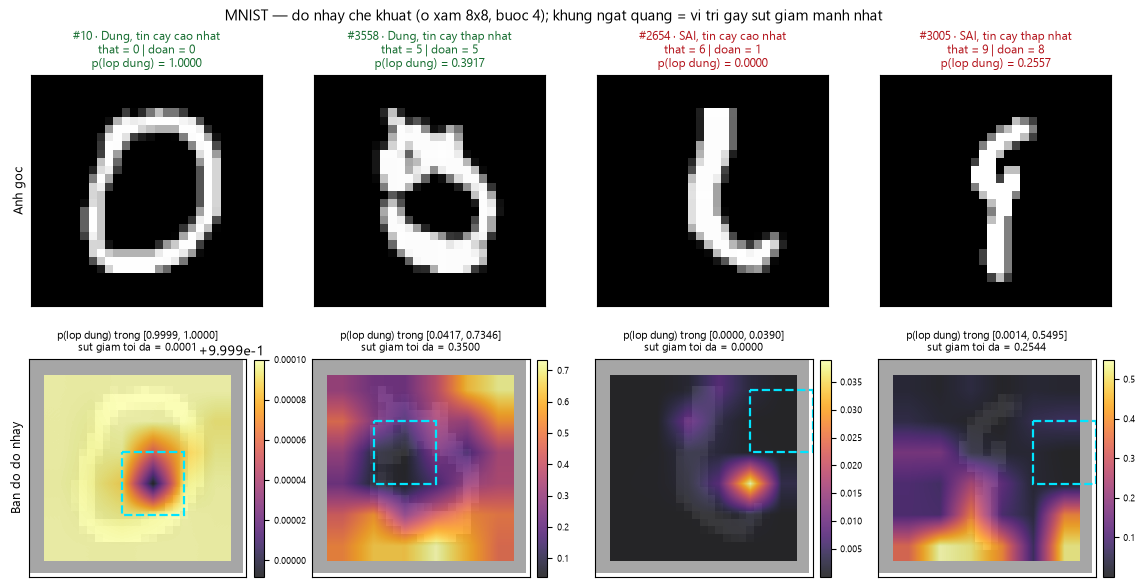

In [15]:
def draw_occlusion(subfig, bd, items):
    n = len(items)
    axs = subfig.subplots(2, n)
    axs = np.atleast_2d(axs)
    for j, it in enumerate(items):
        img = bd["x_test"][it["index"]]
        H, W = img.shape[0], img.shape[1]

        ax = axs[0][j]
        ax.imshow(img, cmap=bd["cmap"], interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        ok = it["y_true"] == it["y_pred"]
        ax.set_title(f"#{it['index']} · {it['tag']}\nthat = {bd['classes'][it['y_true']]}"
                     f" | doan = {bd['classes'][it['y_pred']]}\n"
                     f"p(lop dung) = {it['p0']:.4f}",
                     fontsize=8.5, color="#146c2e" if ok else "#b3121a")

        ax = axs[1][j]
        ax.imshow(img, cmap=bd["cmap"], interpolation="nearest", alpha=0.35)
        ext = (it["cols"][0] + PATCH / 2 - STRIDE / 2, it["cols"][-1] + PATCH / 2 + STRIDE / 2,
               it["rows"][-1] + PATCH / 2 + STRIDE / 2, it["rows"][0] + PATCH / 2 - STRIDE / 2)
        im = ax.imshow(it["grid"], cmap="inferno", extent=ext, alpha=0.78,
                       interpolation="bilinear", vmin=it["pmin"], vmax=it["pmax"])
        # danh dau o che gay sut giam manh nhat
        r0 = it["rows"][it["argmin"][0]]; c0 = it["cols"][it["argmin"][1]]
        ax.add_patch(Rectangle((c0, r0), PATCH, PATCH, fill=False,
                               edgecolor="#00e5ff", linewidth=1.6, linestyle="--"))
        ax.set_xlim(0, W); ax.set_ylim(H, 0)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"p(lop dung) trong [{it['pmin']:.4f}, {it['pmax']:.4f}]\n"
                     f"sut giam toi da = {it['p0'] - it['pmin']:.4f}", fontsize=8)
        cb = subfig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.ax.tick_params(labelsize=6.5)
    axs[0][0].set_ylabel("Anh goc", fontsize=9)
    axs[1][0].set_ylabel("Ban do do nhay", fontsize=9)
    subfig.suptitle(f"{bd['name']} — do nhay che khuat (o xam {PATCH}x{PATCH}, buoc {STRIDE}); "
                    f"khung ngat quang = vi tri gay sut giam manh nhat", fontsize=11)


fig = plt.figure(figsize=(14.0, 6.6 * len(ORDER)))
subfigs = fig.subfigures(len(ORDER), 1, hspace=0.08)
subfigs = np.atleast_1d(subfigs)
for sf, key in zip(subfigs, ORDER):
    draw_occlusion(sf, BUNDLES[key], OCCL[key])
save_fig(fig, "fig_occlusion_sensitivity.png")
plt.show()

### Diễn giải Hình `fig_occlusion_sensitivity.png`

Lưới che là $6\times6$ vị trí trên mỗi ảnh $28\times28$, ứng với 36 lần suy luận cho mỗi ảnh.
Thang màu được chuẩn hóa **riêng cho từng ảnh**, vì biên độ thay đổi giữa bốn ảnh chênh nhau hơn
ba bậc độ lớn; khoảng giá trị thật luôn được ghi trong tiêu đề mỗi panel. Khung nét đứt màu lam
đánh dấu vị trí ô che gây sụt giảm mạnh nhất.

**Ảnh #10, chữ số 0, đúng và tin cậy 1,0000.** Xác suất lớp đúng dao động trong
$[0{,}999892;\,1{,}000000]$, tức **sụt giảm tối đa chỉ 0,000108**. Không một ô che $8\times8$ nào
làm mô hình lung lay. Điểm tối nhất nằm đúng ở **giữa vòng tròn**, tức phần rỗng của chữ số 0, là
vị trí có ý nghĩa vì che vào đó sẽ lấp lỗ và làm chữ 0 bớt giống chữ 0. Nhưng hiệu ứng nhỏ đến
mức chỉ đọc được nhờ thang màu co lại tới cỡ $10^{-4}$. Kết luận trung thực cho ảnh này là:
**thông tin nhận dạng bị dư thừa mạnh**, chữ số 0 được nhận ra từ nhiều vùng độc lập nên phá một
vùng không đủ để phá quyết định.

**Ảnh #3558, chữ số 5, đúng nhưng tin cậy thấp nhất 0,3917.** Đây là ảnh cho tín hiệu rõ nhất
trong bốn ảnh, và nó ủng hộ kết luận **mô hình nhìn vào vật thể**. Xác suất đi từ 0,3917 xuống
0,0417 khi ô che đặt tại góc $(8,8)$, tức **sụt giảm 0,3500** và làm mất hoàn toàn dự đoán đúng.
Vị trí đó phủ lên chỗ nối giữa nét ngang trên và thân dưới của chữ 5, đúng là bộ phận phân biệt
chữ 5 với các chữ số khác. Ngược lại, xác suất **tăng** lên tới 0,7346 khi ô che đặt ở góc
$(20,12)$, tức vùng phía dưới; che ở đó loại bỏ một phần nét gây nhiễu và làm mô hình tự tin hơn
gần gấp đôi so với ảnh gốc. Bản đồ nhiệt sáng ở rìa và tối ở giữa vật thể chính là dấu hiệu của
một mô hình bám vào vật thể chứ không bám vào nền.

**Ảnh #2654, chữ số 6 bị đoán thành 1 với độ tin cậy 0,999923.** Đây chính là hiện tượng "sai với
độ tin cậy cao" mà Chương 6 mô tả, và phép che khuất cho một câu trả lời đáng chú ý:
$p(\text{lớp }6)$ dao động trong $[0{,}000004;\,0{,}039025]$, còn giá trị ban đầu là 0,000045.
Nghĩa là **không tồn tại một ô che $8\times8$ nào khôi phục được lớp đúng**; ngay cả vị trí tốt
nhất cũng chỉ nâng $p(6)$ lên 0,039, còn xa mức cần để thắng lớp 1. Nhìn ảnh gốc thì hiểu tại
sao: chữ số này được viết thành một nét gần như thẳng đứng với vòng dưới rất nhỏ và hở, nên về
mặt hình ảnh nó thực sự giống chữ 1. Kết luận đúng là lỗi này **không do mô hình bám vào một vùng
nhiễu cục bộ nào**; nó là một lỗi phân bố trên toàn ảnh, bắt nguồn từ chính chữ viết. Đây là một
kết quả âm tính có giá trị, vì nó loại trừ giả thuyết "lối tắt thống kê" cho trường hợp này.

**Ảnh #3005, chữ số 9 bị đoán thành 8 với độ tin cậy 0,3401.** Ảnh này cho kết quả mạnh nhất về
mặt chẩn đoán. $p(\text{lớp }9)$ ban đầu là 0,2557, giảm xuống 0,0014 khi che tại $(8,20)$, nhưng
**tăng lên 0,5495 khi che tại $(20,4)$**, tức vùng dưới bên trái. Mức 0,5495 đủ để lớp 9 vượt lên
dẫn đầu, nghĩa là **chỉ cần che đi một vùng $8\times8$ ở góc dưới trái là dự đoán sẽ được sửa
thành đúng**. Nhìn ảnh gốc thấy rõ nguyên nhân: chữ 9 này có một nét kéo dài xuống dưới bên trái
làm phần thân dưới khép lại, khiến hình tổng thể giống chữ 8. Ở đây phép che khuất không chỉ mô
tả mà còn **định vị được nguyên nhân gây lỗi** trên ảnh.

#### Tổng kết Phần D

Trên MNIST, bằng chứng nghiêng hẳn về phía **mô hình nhìn vào vật thể chứ không bám vào nền**:
ở cả hai ảnh mà xác suất thực sự biến động (số 5 và số 9), vùng gây sụt giảm mạnh nhất đều nằm
**trên nét chữ**, còn vùng nền cho xác suất bằng hoặc cao hơn mức ban đầu. Không thấy dấu hiệu
lối tắt thống kê kiểu bám vào một góc nền cố định.

Tuy nhiên có ba điểm hạn chế cần ghi nhận để không kết luận quá tay. Thứ nhất, ô che mang giá trị
xám 0,5 trong khi nền MNIST là 0 và nét là gần 1, nên bản thân ô che là một kích thích **nằm ngoài
phân phối huấn luyện**; một phần phản ứng của mô hình có thể là phản ứng với sự bất thường đó chứ
không phải với việc mất thông tin. Thứ hai, lưới $6\times6$ với bước 4 là rất thô trên ảnh
$28\times28$, nên bản đồ nhiệt chỉ định vị được ở mức vùng chứ không ở mức nét. Thứ ba, với những
ảnh mà mô hình đã cực kỳ tự tin, như ảnh #10, độ nhạy che khuất gần như không đo được gì: phương
pháp này chỉ có sức phân giải ở những ảnh mà mô hình còn do dự.

---

## 8. Lưu kết quả ra `reports/metrics_anatomy.json`

Mọi con số dưới đây đến từ chính các ô lệnh đã chạy ở trên, không có giá trị nào được nhập tay.
Khóa và cấu trúc theo đúng đặc tả Mục 8.2 của hợp đồng tích hợp.

In [16]:
def jsonable(x):
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    return x


payload = {"calibration": {}, "filters": {}, "occlusion": {}}

for key in ORDER:
    bd, c = BUNDLES[key], CALIB[key]
    payload["calibration"][key] = {
        "ece_before": c["before"]["ece"],
        "ece_after": c["after"]["ece"],
        "temperature": c["T"],
        "n_bins": N_BINS,
        "bin_acc": c["before"]["bin_acc"],
        "bin_conf": c["before"]["bin_conf"],
        "bin_count": c["before"]["bin_count"],
        "bin_acc_after": c["after"]["bin_acc"],
        "bin_conf_after": c["after"]["bin_conf"],
        "bin_count_after": c["after"]["bin_count"],
        "test_accuracy": c["before"]["accuracy"],
        "mean_confidence_before": c["before"]["mean_conf"],
        "mean_confidence_after": c["after"]["mean_conf"],
        "nll_test_before": c["before"]["nll"],
        "nll_test_after": c["after"]["nll"],
        "nll_val_before": c["nll_val_before"],
        "nll_val_after": c["nll_val_after"],
        "fit_split": "validation",
        "n_val": int(len(bd["y_val"])),
        "n_test": int(len(bd["y_test"])),
        "checkpoint_sha1": bd["sha1"],
        "high_confidence_tail": {
            "n_wrong_total": TAIL[key]["n_wrong"],
            "max_confidence_among_wrong": TAIL[key]["max_conf_wrong"],
            "by_threshold": [{"threshold": t, "n": n, "n_wrong": w, "accuracy": a}
                             for (t, n, w, a) in TAIL[key]["rows"]],
            "ece_if_high_conf_errors_fixed": TAIL[key]["ece_if_fix_099"],
            "ece_if_last_bin_errors_fixed": TAIL[key]["ece_if_fix_last_bin"],
        },
    }
    f = FILTERS[key]
    payload["filters"][key] = {
        "n_filters": f["n_filters"],
        "shape": f["shape"],
        "abs_mean": f["abs_mean"],
        "std": f["std"],
        "w_min": f["wmin"],
        "w_max": f["wmax"],
        "kernel_sum_abs_mean": float(np.abs(f["sums"]).mean()),
        "n_near_zero_sum": f["n_zero_sum"],
    }
    payload["occlusion"][key] = [
        {"index": it["index"], "true": it["y_true"], "pred": it["y_pred"],
         "prob_drop_max": float(it["p0"] - it["pmin"]),
         "selection": it["tag"], "confidence": it["conf"],
         "prob_true_original": it["p0"], "prob_true_min": it["pmin"],
         "prob_true_max": it["pmax"],
         "argmin_row_col": [it["rows"][it["argmin"][0]], it["cols"][it["argmin"][1]]],
         "argmax_row_col": [it["rows"][it["argmax"][0]], it["cols"][it["argmax"][1]]],
         "grid_shape": [len(it["rows"]), len(it["cols"])]}
        for it in OCCL[key]
    ]

payload["config"] = {
    "n_bins": N_BINS, "occlusion_patch": PATCH, "occlusion_stride": STRIDE,
    "occlusion_grey_value": GREY, "random_seed": SEED,
    "device": torch.cuda.get_device_name(0), "torch_version": torch.__version__,
    "temperature_fit_split": "validation", "temperature_optimizer": "L-BFGS tren log T",
    "datasets_included": list(ORDER),
}
payload["notes"] = "Notebook 05_model_anatomy.ipynb mo xe mo hinh CNN da huan luyen, KHONG huan luyen lai: trong so nap tu mnist/models/mnist_cnn_pytorch.pt. Suy luan tren GPU (RTX 4060 Laptop) voi model.eval() nen Dropout tat va BatchNorm dong bang. HIEU CHINH XAC SUAT: ECE dung 15 khoang deu tren [0,1], khoang nua mo [lo, hi); khoang rong dong gop 0. Nhiet do T duoc khop BANG L-BFGS TREN TAP VALIDATION VA CHI TREN TAP VALIDATION (12 000 anh MNIST tach ra bang train_test_split(test_size=0.2, stratify=y, random_state=42), dung phep chia da dung luc huan luyen); tap test 10 000 anh chi dung de BAO CAO ECE truoc va sau. Khop T tren tap test se la ro ri du lieu va lam vo hieu toan bo muc nay. T duoc tham so hoa qua log T de rang buoc T > 0 tu dong. Vi T > 0 khong doi thu tu logit nen accuracy khong doi sau hieu chinh, va dieu nay da duoc kiem tra trong output. CANH BAO KHI DOC ECE: ECE la mot trung binh co trong so tren toan bo tap test, nen mot nhom nho du doan sai voi do tin cay cao gan nhu khong lam no thay doi. Voi MNIST, 97,1% so anh nam trong khoang cuoi cung nen khoang do chi phoi ECE. Do do ECE thap KHONG cho phep tin vao tung du doan rieng le; phan high_confidence_tail trong tep nay ghi lai so anh sai theo tung nguong do tin cay de doc gia danh gia duoc rui ro o duoi. Dac biet, gia dinh sua het cac anh sai trong khoang cuoi thanh dung se lam ECE TANG chu khong giam, vi khoang do chuyen tu hoi qua tu tin sang hoi thieu tu tin: mot mo hinh chinh xac hon van co the co ECE te hon. BO LOC TANG MOT: moi kernel duoc chuan hoa DOC LAP khi hien thi (MNIST dung thang phan ky RdBu_r voi gioi han doi xung +-max|w| cua rieng kernel do; anh RGB chuan hoa chung ba kenh trong pham vi tung kernel de giu quan he mau). s_f la tong trong so, do dap ung voi vung dong nhat. Bang doi chieu voi nam mau 3x3 kinh dien chi la cach sap xep tho: |cos| lon nhat trung binh chi 0,5346 va 25/32 kernel duoi 0,6, nen KHONG duoc doc bang do nhu tuyen bo rang mang hoc ra dung bo loc Sobel. BAN DO DAC TRUNG: chon anh test dau tien duoc phan loai DUNG (tat dinh). Moi khoi ve 8 kenh co kich hoat trung binh lon nhat tren chinh anh do, khong phai 8 kenh dau, vi sau ReLU nhieu kenh tat han tren mot anh cu the. DO NHAY CHE KHUAT: o vuong xam gia tri 0,5 tren thang [0,1], kich thuoc 8x8, buoc nhay 4, ap TRUOC khi chuan hoa. Chi lay cac vi tri ma o che nam tron trong anh, nen luoi la 6x6 = 36 vi tri voi anh 28x28. Bon anh moi mien duoc chon bang quy tac 2x2 TAT DINH tren hai truc dung/sai va tu tin/do du: (1) dung voi do tin cay cao nhat, (2) dung voi do tin cay thap nhat, (3) sai voi do tin cay cao nhat, (4) sai voi do tin cay thap nhat; dong hang bang chi so nho nhat. Chon nhu vay de bao phu du cac che do hanh xu, va truong hop (3) chinh la hien tuong 'sai voi do tin cay cao' ma Chuong 6 va 7 mo ta. prob_drop_max = prob_true_original - prob_true_min, co the rat nho voi anh ma mo hinh vo cung tu tin, va co the am y nghia khi che lam TANG xac suat lop dung (truong hop do doc o prob_true_max). HAN CHE CAN GHI NHAN: (a) o che xam 0,5 la kich thich nam ngoai phan phoi huan luyen cua MNIST (nen 0, net gan 1), nen mot phan phan ung co the la phan ung voi su bat thuong chu khong phai voi viec mat thong tin; (b) luoi 6x6 buoc 4 rat tho tren anh 28x28 nen chi dinh vi duoc o muc vung, khong o muc net; (c) voi anh ma mo hinh da cuc ky tu tin thi do nhay che khuat gan nhu khong do duoc gi, phuong phap chi co suc phan giai o nhung anh mo hinh con do du; (d) chin khoang ECE o giua chi chua tong cong 290 anh nen acc theo khoang o do rat nhieu va khong nen doc nhu bang chung."

out_path = os.path.join(REPORT_DIR, "metrics_anatomy.json")
with open(out_path, "w", encoding="utf-8") as fh:
    json.dump(payload, fh, ensure_ascii=False, indent=2, default=jsonable)
print(f"Da ghi {out_path}  ({os.path.getsize(out_path) / 1024:.1f} KB)")
print(json.dumps({k: (list(v) if isinstance(v, dict) else v)
                  for k, v in payload.items() if k != "notes"},
                 ensure_ascii=False)[:400], "...")

Da ghi ..\reports\metrics_anatomy.json  (10.0 KB)
{"calibration": ["mnist"], "filters": ["mnist"], "occlusion": ["mnist"], "config": ["n_bins", "occlusion_patch", "occlusion_stride", "occlusion_grey_value", "random_seed", "device", "torch_version", "temperature_fit_split", "temperature_optimizer", "datasets_included"]} ...


---

## 9. Kết luận của notebook

Bốn phép mổ xẻ ở trên cho bốn kết luận độc lập, và không phép nào trong số đó đọc được từ một
bảng accuracy.

**1. Về hiệu chỉnh xác suất.** Mô hình CNN trên MNIST có ECE 0,002232 với 15 khoảng, và nhiệt độ
tối ưu khớp trên tập validation là $T = 1{,}2318$. Vì $T > 1$, mô hình **quá tự tin**, nhưng mức
quá tự tin là **nhẹ**: hiệu chỉnh nhiệt độ chỉ hạ ECE xuống 0,001759 và gần như không đổi NLL
trên tập test. Kết quả này **trái với kỳ vọng ban đầu** của notebook và báo cáo giữ nguyên số đo.

**2. Về mâu thuẫn biểu kiến với Chương 6 và Chương 7.** ECE thấp và "sai với độ tin cậy cao" cùng
đúng, vì chúng nói về hai đại lượng khác nhau. ECE là trung bình có trọng số trên 10 000 dự đoán
nên một nhóm nhỏ dự đoán sai tự tin không làm nó dịch chuyển. Cụ thể: 6 ảnh sai ở mức tin cậy từ
0,99 trở lên, và ảnh tệ nhất sai ở mức 0,999923. Phản chứng định lượng còn mạnh hơn: nếu sửa hết
22 ảnh sai trong khoảng cuối thành đúng thì ECE **tăng** từ 0,002232 lên 0,002371. **Một mô hình
chính xác hơn có thể có ECE tệ hơn.** Do đó ECE thấp là điều kiện cần chứ không đủ để tin vào
từng dự đoán riêng lẻ.

**3. Về những gì tầng một học được.** 32 kernel $3\times3\times1$ học ra các bộ dò tương phản cục
bộ có hướng, cùng một nhóm nhỏ bộ dò cường độ với tổng trọng số lớn. Không có cấu trúc Gabor sạch,
và phép đối chiếu với năm mẫu kinh điển cho $|\cos|$ lớn nhất trung bình chỉ 0,5346 với 25 trên 32
kernel dưới ngưỡng 0,6. Báo cáo kết luận rằng các kernel là **tổ hợp lai không chuẩn hoá**, và
nêu rõ lý do hình học: chín tham số là quá ít để dựng một bộ lọc Gabor.

**4. Về vùng ảnh chi phối quyết định.** Phép che khuất cho thấy mô hình **nhìn vào nét chữ chứ
không bám vào nền**. Sụt giảm xác suất lớn nhất đo được là 0,3500 trên ảnh #3558, và trên ảnh
#3005 việc che một vùng $8\times8$ ở góc dưới trái nâng xác suất lớp đúng từ 0,2557 lên 0,5495,
đủ để sửa dự đoán sai thành đúng. Ngược lại, với ảnh #2654 không ô che nào khôi phục được lớp
đúng, cho thấy lỗi đó bắt nguồn từ hình dạng chữ viết chứ không từ một vùng nhiễu cục bộ.

### Giá trị đóng góp

Một trong hai bài tham khảo chỉ ghi "có thể bổ sung hiệu chỉnh xác suất" vào phần hướng phát
triển. Notebook này đo thật, và thu được không chỉ một con số mà cả một kết luận phương pháp luận
ngược chiều trực giác về giới hạn của chính chỉ số ấy. Cả hai bài tham khảo đều không cho thấy
mạng đã học được gì bên trong; notebook này vẽ toàn bộ bộ lọc tầng một, đo mức khớp của chúng với
các mẫu kinh điển thay vì mô tả cảm tính, theo dõi biểu diễn qua từng khối, và định vị được vùng
ảnh chịu trách nhiệm cho một dự đoán sai cụ thể.